In [3]:
# ### Checkpoint setup for Google Drive + local fallback
# Run this before the long experiment cells. In Colab it asks for Drive permission once.
# Checkpoints are loaded from Drive first, then the current folder. Saves go to both when possible.

from pathlib import Path
import torch
SAVE_CHECKPOINTS = True
LOAD_CHECKPOINTS = True

LOCAL_CHECKPOINT_DIR = Path.cwd() / 'cs159_memory_diffusion_checkpoints'
CHECKPOINT_DIRS = []
DRIVE_CHECKPOINT_DIR = None

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_CHECKPOINT_DIR = Path('/content/drive/MyDrive/cs159_memory_diffusion_checkpoints')
    CHECKPOINT_DIRS.append(DRIVE_CHECKPOINT_DIR)
    print('Google Drive mounted.')
except Exception as e:
    print(f'Google Drive mount skipped ({type(e).__name__}: {e}). Local checkpoints will be used.')

CHECKPOINT_DIRS.append(LOCAL_CHECKPOINT_DIR)

# Remove duplicates while preserving order.
_unique_dirs = []
for _d in CHECKPOINT_DIRS:
    if _d not in _unique_dirs:
        _unique_dirs.append(_d)
CHECKPOINT_DIRS = _unique_dirs

for _d in CHECKPOINT_DIRS:
    try:
        _d.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        print(f'Could not create checkpoint dir {_d}: {type(e).__name__}: {e}')

# Backward-compatible primary directory: Drive if mounted, otherwise local.
CHECKPOINT_DIR = CHECKPOINT_DIRS[0]

def checkpoint_paths(filename):
    return [d / filename for d in CHECKPOINT_DIRS]

def load_checkpoint_file(filename, map_location=None):
    for path in checkpoint_paths(filename):
        if path.exists():
            ckpt = torch.load(path, map_location=map_location)
            print(f'Loaded checkpoint from {path}')
            return ckpt, path
    print(f'No checkpoint found for {filename}. Checked: {[str(p) for p in checkpoint_paths(filename)]}')
    return None, None

def save_checkpoint_file(payload, filename):
    saved = []
    for path in checkpoint_paths(filename):
        try:
            path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(payload, path)
            saved.append(path)
            print(f'Saved checkpoint to {path}')
        except Exception as e:
            print(f'Could not save checkpoint to {path}: {type(e).__name__}: {e}')
    if not saved:
        raise RuntimeError(f'Failed to save checkpoint {filename} to every configured directory')
    return saved

print('Checkpoint load order:', [str(d) for d in CHECKPOINT_DIRS])
print('Primary checkpoint directory:', CHECKPOINT_DIR)
print('SAVE_CHECKPOINTS:', SAVE_CHECKPOINTS, 'LOAD_CHECKPOINTS:', LOAD_CHECKPOINTS)

Mounted at /content/drive
Google Drive mounted.
Checkpoint load order: ['/content/drive/MyDrive/cs159_memory_diffusion_checkpoints', '/content/cs159_memory_diffusion_checkpoints']
Primary checkpoint directory: /content/drive/MyDrive/cs159_memory_diffusion_checkpoints
SAVE_CHECKPOINTS: True LOAD_CHECKPOINTS: True


In [4]:
!pip -q install sentence-transformers datasets tqdm

import json, math, random, re, hashlib
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm

import torch
from torch import nn
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

# =========================
# CONFIG
# =========================

OUTPUT_DIR = Path("/content/outputs/residual_diffusion_reranker")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_CONVERSATIONS = 500
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

EPOCHS = 60
T = 20
BATCH_SIZE = 128
HIDDEN_DIM = 512
N_LAYERS = 4
LR = 3e-4
TOP_K = 5
CORRUPTION_SEVERITY = 0.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================
# UTILS
# =========================

def check(cond, msg):
    if cond:
        print(f"  ✓ {msg}")
    else:
        raise RuntimeError(f"FAIL: {msg}")

def normalize_np(x):
    return x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-12)

def info(msg):
    print(f"  ℹ {msg}")

# =========================
# LOAD REAL MSC
# =========================

print("\nSTAGE 0: Load MSC")
ds = load_dataset("nayohan/multi_session_chat", split="train")

records = []
for i, row in enumerate(ds):
    if MAX_CONVERSATIONS and i >= MAX_CONVERSATIONS:
        break
    records.append(dict(row))

check(len(records) > 0, f"Loaded {len(records)} MSC conversations")

# =========================
# PARSE FACTS
# =========================

FIRST_PERSON_MAP = [
    (r"\bI am\b", "The user is"),
    (r"\bI'm\b", "The user is"),
    (r"\bI have\b", "The user has"),
    (r"\bI've\b", "The user has"),
    (r"\bI like\b", "The user likes"),
    (r"\bI love\b", "The user loves"),
    (r"\bI enjoy\b", "The user enjoys"),
    (r"\bI hate\b", "The user hates"),
    (r"\bI dislike\b", "The user dislikes"),
    (r"\bI work\b", "The user works"),
    (r"\bI live\b", "The user lives"),
    (r"\bI play\b", "The user plays"),
    (r"\bI study\b", "The user studies"),
    (r"\bMy\b", "The user's"),
    (r"\bmy\b", "the user's"),
]

def to_third_person(fact):
    s = str(fact).strip()
    s = re.sub(r"^\s*[-*]\s*", "", s)
    s = s.rstrip(".!?")
    changed = False

    for pat, repl in FIRST_PERSON_MAP:
        if re.search(pat, s):
            s = re.sub(pat, repl, s)
            changed = True

    if not changed and s and not s.lower().startswith("the user"):
        s = "The user " + s[0].lower() + s[1:]

    s = re.sub(r"\s+", " ", s).strip()
    if s:
        s = s[0].upper() + s[1:]
    return s + "."

def get_persona_facts(raw):
    out = []
    for k in ["persona1", "persona2", "persona", "personas"]:
        if k in raw:
            v = raw[k]
            if isinstance(v, list):
                out.extend([str(x).strip() for x in v if str(x).strip()])
            elif isinstance(v, str):
                out.extend([x.strip() for x in v.splitlines() if x.strip()])
    return out

def fact_to_query(fact):
    l = fact.lower()
    if any(w in l for w in ["likes", "loves", "enjoys", "favorite", "hobby"]):
        return "What does the user enjoy or like?"
    if " has " in l:
        return "What does the user have?"
    if any(w in l for w in ["works", "job", "career", "teacher", "engineer", "nurse"]):
        return "What does the user do for work?"
    if any(w in l for w in ["lives", "from", "grew up"]):
        return "Where does the user live or come from?"
    if " plays " in l:
        return "What does the user play?"
    if " studies " in l:
        return "What does the user study?"
    return "What is an important fact about the user?"

print("\nSTAGE 1: Extract MSC facts")

examples = []
all_facts = []
seen = set()

for idx, raw in enumerate(records):
    cid = str(raw.get("dialoug_id", raw.get("conversation_id", f"conv_{idx}")))
    facts = [to_third_person(f) for f in get_persona_facts(raw)]
    facts = [f for f in facts if len(f.split()) >= 4]

    for f in facts:
        if f.lower() not in seen:
            seen.add(f.lower())
            all_facts.append(f)

    for j, target in enumerate(facts):
        examples.append({
            "example_id": f"{cid}_{j}",
            "conversation_id": cid,
            "query": fact_to_query(target),
            "target_context": target,
            "clean_memory_facts": facts,
        })

check(len(all_facts) > 100, f"Unique facts: {len(all_facts)}")
check(len(examples) > 100, f"Examples: {len(examples)}")

# =========================
# CORRUPT MEMORY
# =========================

print("\nSTAGE 2: Corrupt memory")

ANTONYM_SWAPS = [
    (r"\blikes\b", "dislikes"),
    (r"\bloves\b", "hates"),
    (r"\benjoys\b", "dislikes"),
    (r"\bhas\b", "does not have"),
    (r"\bis\b", "is not"),
    (r"\bworks\b", "does not work"),
    (r"\blives\b", "does not live"),
    (r"\bplays\b", "does not play"),
]

def contradict(fact):
    for pat, repl in ANTONYM_SWAPS:
        if re.search(pat, fact, flags=re.I):
            return re.sub(pat, repl, fact, count=1, flags=re.I)
    return fact.replace("The user ", "The user does not ", 1)

rng = random.Random(42)

for ex in examples:
    clean = ex["clean_memory_facts"]
    other = [f for f in all_facts if f not in clean]

    corrupted = list(clean)

    if clean and rng.random() < CORRUPTION_SEVERITY:
        corrupted.append(contradict(rng.choice(clean)))

    if other:
        corrupted.extend(rng.sample(other, min(4, len(other))))

    rng.shuffle(corrupted)

    ex["corrupted_memory_facts"] = corrupted
    ex["corrupted_memory_text"] = " ".join(corrupted)

    h = int(hashlib.md5(ex["conversation_id"].encode()).hexdigest(), 16) % 100
    ex["split"] = "train" if h < 60 else ("valid" if h < 80 else "test")

splits = {s: sum(e["split"] == s for e in examples) for s in ["train", "valid", "test"]}
check(splits["train"] > 0 and splits["test"] > 0, f"Splits: {splits}")

# =========================
# SBERT EMBEDDINGS
# =========================

print("\nSTAGE 3: SBERT embeddings")

sbert = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)

def encode(texts, batch_size=128):
    return sbert.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype(np.float32)

queries = [e["query"] for e in examples]
targets = [e["target_context"] for e in examples]
mem_texts = [e["corrupted_memory_text"] for e in examples]

query_embs = encode(queries)
target_embs = encode(targets)
memory_embs = encode(mem_texts)

dim = query_embs.shape[1]
check(query_embs.shape == target_embs.shape, f"Embedding shape: {query_embs.shape}")

# =========================
# BUILD TOP-K DATA
# =========================

print("\nSTAGE 4: Build top-k retrieval data")

top1_embs = []
topk_flat_embs = []
topk_fact_indices = []
raw_top1_correct = []
topk_oracle = []

for i, ex in enumerate(tqdm(examples)):
    facts = ex["corrupted_memory_facts"]
    target = ex["target_context"]

    fact_embs = encode(facts)
    q = query_embs[i]

    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]

    top1_idx = order[0]
    raw_top1_correct.append(facts[top1_idx].strip().lower() == target.strip().lower())

    topk_idx = order[:TOP_K]
    topk_oracle.append(
        any(facts[j].strip().lower() == target.strip().lower() for j in topk_idx)
    )

    top1 = fact_embs[top1_idx]
    topk = fact_embs[topk_idx]

    if len(topk) < TOP_K:
        pad = np.repeat(topk[-1:], TOP_K - len(topk), axis=0)
        topk = np.concatenate([topk, pad], axis=0)

    top1_embs.append(top1)
    topk_flat_embs.append(topk.reshape(-1))
    topk_fact_indices.append(topk_idx)

top1_embs = np.stack(top1_embs).astype(np.float32)
topk_flat_embs = np.stack(topk_flat_embs).astype(np.float32)

raw_all = np.mean(raw_top1_correct)
oracle_all = np.mean(topk_oracle)

info(f"Raw SBERT top-1 all-example acc: {raw_all:.4f}")
info(f"Top-{TOP_K} oracle all-example acc: {oracle_all:.4f}")

# =========================
# RESIDUAL TARGET
# =========================

print("\nSTAGE 5: Train residual diffusion")

residuals = target_embs - top1_embs

# Important: residuals are much smaller than full embeddings.
residual_scale = np.std(residuals).astype(np.float32)
residuals_scaled = residuals / (residual_scale + 1e-8)

info(f"Residual scale: {residual_scale:.6f}")
info(f"Mean residual norm: {np.linalg.norm(residuals, axis=1).mean():.4f}")

train_idx = np.array([i for i, e in enumerate(examples) if e["split"] == "train"])

r_train = torch.tensor(residuals_scaled[train_idx], dtype=torch.float32, device=DEVICE)
q_train = torch.tensor(query_embs[train_idx], dtype=torch.float32, device=DEVICE)
m_train = torch.tensor(memory_embs[train_idx], dtype=torch.float32, device=DEVICE)
top1_train = torch.tensor(top1_embs[train_idx], dtype=torch.float32, device=DEVICE)
topk_train = torch.tensor(topk_flat_embs[train_idx], dtype=torch.float32, device=DEVICE)

cond_train = torch.cat([q_train, m_train, top1_train, topk_train], dim=-1)

steps = torch.arange(T + 1, dtype=torch.float64)
alpha_bar_full = torch.cos(((steps / T) + 0.008) / 1.008 * math.pi * 0.5) ** 2
alpha_bar_full = alpha_bar_full / alpha_bar_full[0]

betas = torch.clamp(
    1 - (alpha_bar_full[1:] / alpha_bar_full[:-1]),
    0.0001,
    0.2,
).float().to(DEVICE)

alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)
sqrt_ab = torch.sqrt(alpha_bar)
sqrt_1_ab = torch.sqrt(1.0 - alpha_bar)

class SinTime(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.d = d

    def forward(self, t):
        half = self.d // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

class FiLMBlock(nn.Module):
    def __init__(self, hidden, cond_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden)
        self.fc1 = nn.Linear(hidden, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.film = nn.Linear(cond_dim, hidden * 2)
        self.act = nn.GELU()
        self.drop = nn.Dropout(0.1)

    def forward(self, x, c):
        h = self.act(self.fc1(self.norm(x)))
        g, b = self.film(c).chunk(2, dim=-1)
        h = h * (1 + g) + b
        return x + self.drop(self.fc2(h))

class ResidualDenoiser(nn.Module):
    def __init__(self, embed_dim, hidden_dim, n_layers, top_k):
        super().__init__()
        td = 128
        cond_in = embed_dim * (3 + top_k)

        self.time_mlp = nn.Sequential(
            SinTime(td),
            nn.Linear(td, td),
            nn.GELU(),
            nn.Linear(td, td),
        )

        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_in, td),
            nn.GELU(),
            nn.Linear(td, td),
        )

        self.inp = nn.Linear(embed_dim, hidden_dim)
        self.blocks = nn.ModuleList([FiLMBlock(hidden_dim, td) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, embed_dim))

    def forward(self, r_t, t, cond):
        c = self.time_mlp(t) + self.cond_mlp(cond)
        h = self.inp(r_t)
        for blk in self.blocks:
            h = blk(h, c)
        return self.out(h)

model = ResidualDenoiser(dim, HIDDEN_DIM, N_LAYERS, TOP_K).to(DEVICE)
info(f"Params: {sum(p.numel() for p in model.parameters()):,}")

# Checkpoint path for the older simple fact_to_query residual diffusion model.
if "CHECKPOINT_DIR" not in globals():
    CHECKPOINT_DIR = Path("./cs159_memory_diffusion_checkpoints")
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
if "SAVE_CHECKPOINTS" not in globals(): SAVE_CHECKPOINTS = True
if "LOAD_CHECKPOINTS" not in globals(): LOAD_CHECKPOINTS = True
simple_residual_ckpt_name = "simple_fact_query_residual_diffusion.pt"
simple_residual_ckpt_path = CHECKPOINT_DIR / simple_residual_ckpt_name
simple_residual_ckpt = None
simple_residual_loaded = False
if LOAD_CHECKPOINTS:
    if "load_checkpoint_file" in globals():
        simple_residual_ckpt, _loaded_path = load_checkpoint_file(simple_residual_ckpt_name, map_location=DEVICE)
        if _loaded_path is not None:
            simple_residual_ckpt_path = _loaded_path
    elif simple_residual_ckpt_path.exists():
        simple_residual_ckpt = torch.load(simple_residual_ckpt_path, map_location=DEVICE)
if simple_residual_ckpt is not None:
    expected = {"dim": dim, "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS, "top_k": TOP_K, "T": T}
    got = {k: simple_residual_ckpt.get(k) for k in expected}
    if got == expected:
        model.load_state_dict(simple_residual_ckpt["model_state_dict"])
        model.eval()
        history = simple_residual_ckpt.get("history", [])
        simple_residual_loaded = True
        info(f"Loaded simple residual diffusion checkpoint from {simple_residual_ckpt_path}")
    else:
        info(f"Residual checkpoint config mismatch; retraining. expected={expected}, got={got}")

if simple_residual_loaded:
    info("Skipping simple residual diffusion training because checkpoint was loaded.")
else:
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(r_train, cond_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True,
    )

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for r0, cond in loader:
            B = r0.shape[0]
            t = torch.randint(0, T, (B,), device=DEVICE)
            noise = torch.randn_like(r0)

            r_t = sqrt_ab[t, None] * r0 + sqrt_1_ab[t, None] * noise
            pred_noise = model(r_t, t, cond)

            loss = nn.functional.mse_loss(pred_noise, noise)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            losses.append(loss.item())

        sched.step()
        ml = float(np.mean(losses))
        history.append(ml)

        if epoch == 1 or epoch % max(1, EPOCHS // 10) == 0:
            info(f"Epoch {epoch}/{EPOCHS} loss={ml:.6f}")

    check(history[-1] < history[0], f"Loss decreased {history[0]:.4f} -> {history[-1]:.4f}")
    if SAVE_CHECKPOINTS:
        simple_residual_payload = {
            "model_state_dict": model.state_dict(),
            "history": history,
            "dim": dim,
            "hidden_dim": HIDDEN_DIM,
            "n_layers": N_LAYERS,
            "top_k": TOP_K,
            "T": T,
            "epochs": EPOCHS,
            "embedding_model": EMBEDDING_MODEL,
        }
        if "save_checkpoint_file" in globals():
            save_checkpoint_file(simple_residual_payload, simple_residual_ckpt_name)
        else:
            torch.save(simple_residual_payload, simple_residual_ckpt_path)
            info(f"Saved simple residual diffusion checkpoint to {simple_residual_ckpt_path}")

# =========================
# SAMPLE RESIDUAL FROM SDEDIT
# =========================

@torch.no_grad()
def sdedit_residual(r_init, cond, t_start):
    B = r_init.shape[0]

    ts = torch.full((B,), t_start - 1, device=DEVICE, dtype=torch.long)
    noise = torch.randn_like(r_init)

    r_t = sqrt_ab[ts, None] * r_init + sqrt_1_ab[ts, None] * noise

    for i in reversed(range(t_start)):
        t = torch.full((B,), i, device=DEVICE, dtype=torch.long)
        eps = model(r_t, t, cond)

        mean = (1.0 / torch.sqrt(alphas[i])) * (
            r_t - (betas[i] / torch.sqrt(1.0 - alpha_bar[i])) * eps
        )

        if i > 0:
            post_var = betas[i] * (1.0 - alpha_bar[i - 1]) / (1.0 - alpha_bar[i])
            r_t = mean + torch.sqrt(post_var) * torch.randn_like(r_t)
        else:
            r_t = mean

    return r_t

# =========================
# EVALUATE
# =========================

print("\nSTAGE 6: Evaluate residual diffusion reranker")

test_idx = [i for i, e in enumerate(examples) if e["split"] == "test"]
check(len(test_idx) > 0, f"Test examples: {len(test_idx)}")

t_starts = [1, 2, 3, 4, 5]
lambdas = [0.25, 0.5, 0.75, 1.0]

results = {}

for t_start in t_starts:
    for lam in lambdas:
        raw_ok = 0
        diff_ok = 0
        oracle_ok = 0

        for i in tqdm(test_idx, desc=f"t={t_start}, λ={lam}"):
            ex = examples[i]
            facts = ex["corrupted_memory_facts"]
            target = ex["target_context"]

            fact_embs = encode(facts)
            q = query_embs[i]

            scores = fact_embs @ q
            order = np.argsort(scores)[::-1]

            raw_idx = order[0]
            raw_pick = facts[raw_idx]
            raw_ok += int(raw_pick.strip().lower() == target.strip().lower())

            topk_indices = order[:TOP_K]
            oracle_ok += int(any(facts[j].strip().lower() == target.strip().lower() for j in topk_indices))

            top1 = fact_embs[raw_idx]
            topk = fact_embs[topk_indices]

            if len(topk) < TOP_K:
                pad = np.repeat(topk[-1:], TOP_K - len(topk), axis=0)
                topk = np.concatenate([topk, pad], axis=0)

            cond_np = np.concatenate([
                query_embs[i],
                memory_embs[i],
                top1,
                topk.reshape(-1),
            ]).astype(np.float32)

            # Initial residual is zero: start from "no correction".
            r_init = torch.zeros(1, dim, dtype=torch.float32, device=DEVICE)
            cond_t = torch.tensor(cond_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            r_scaled = sdedit_residual(r_init, cond_t, t_start)
            r = r_scaled.detach().cpu().numpy()[0] * residual_scale

            refined_vec = top1 + lam * r
            refined_vec = refined_vec / (np.linalg.norm(refined_vec) + 1e-12)

            candidate_embs = fact_embs[topk_indices]
            refined_scores = candidate_embs @ refined_vec

            chosen_local = int(np.argmax(refined_scores))
            chosen_idx = topk_indices[chosen_local]
            diff_pick = facts[chosen_idx]

            diff_ok += int(diff_pick.strip().lower() == target.strip().lower())

        n = len(test_idx)
        key = (t_start, lam)
        results[key] = {
            "raw_acc": raw_ok / n,
            "diff_acc": diff_ok / n,
            "delta": (diff_ok - raw_ok) / n,
            "oracle": oracle_ok / n,
        }

        r = results[key]
        print(
            f"t={t_start}, λ={lam:.2f} | "
            f"raw={r['raw_acc']:.4f} | "
            f"diff={r['diff_acc']:.4f} | "
            f"Δ={r['delta']:+.4f} | "
            f"top{TOP_K}_oracle={r['oracle']:.4f}"
        )

best_key = max(results, key=lambda k: results[k]["diff_acc"])
best = results[best_key]

print("\nFINAL REPORT")
print("=" * 60)
print(f"MSC conversations: {len(records)}")
print(f"Examples: {len(examples)}")
print(f"Splits: {splits}")
print(f"TOP_K: {TOP_K}")
print(f"Best t_start, lambda: {best_key}")
print(f"Raw SBERT acc: {best['raw_acc']:.4f}")
print(f"Residual diffusion acc: {best['diff_acc']:.4f}")
print(f"Delta: {best['delta']:+.4f}")
print(f"Top-{TOP_K} oracle ceiling: {best['oracle']:.4f}")

DEVICE: cpu

STAGE 0: Load MSC


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00001-537fda2f9aae8a(…):   0%|          | 0.00/16.2M [00:00<?, ?B/s]

data/validation-00000-of-00001-5e685f024(…):   0%|          | 0.00/2.94M [00:00<?, ?B/s]

...

t=5, λ=0.50 | raw=0.1759 | diff=0.1759 | Δ=+0.0000 | top5_oracle=0.5506


t=5, λ=0.75:   0%|          | 0/830 [00:00<?, ?it/s]

t=5, λ=0.75 | raw=0.1759 | diff=0.1759 | Δ=+0.0000 | top5_oracle=0.5506


t=5, λ=1.0:   0%|          | 0/830 [00:00<?, ?it/s]

t=5, λ=1.00 | raw=0.1759 | diff=0.1759 | Δ=+0.0000 | top5_oracle=0.5506

FINAL REPORT
MSC conversations: 500
Examples: 4788
Splits: {'train': 3010, 'valid': 948, 'test': 830}
TOP_K: 5
Best t_start, lambda: (1, 0.25)
Raw SBERT acc: 0.1759
Residual diffusion acc: 0.1759
Delta: +0.0000
Top-5 oracle ceiling: 0.5506


Approach A (Prototype Generation): Generate N target embeddings from noise conditioned on (query, memory_mean), average them into a "prototype" of what the answer should look like, rerank top-K candidates by cosine similarity to the prototype. This is the purest "diffusion for memory" approach.


Approach B (Denoising Score): For each top-K candidate, lightly noise it, denoise it conditioned on (query, memory_mean), measure how much it changes. Correct candidates are already consistent with the conditional distribution and change less. Combine this score with raw cosine for reranking. This is faster (no full reverse process) and uses diffusion as a density estimator.

In [3]:
#!/usr/bin/env python3
"""
Memory Diffusion — Fixed Pipeline (Colab-ready)

WHAT CHANGED FROM V1:
The old code predicted a RESIDUAL from top-1 retrieval. When top-1 is
wrong (82% of the time), the residual depends on WHICH wrong fact was
retrieved — same conditioning, random target direction — so the model
learns to predict zero.

This version has TWO approaches that avoid that problem:

APPROACH A — Conditional Generation:
  Train DDPM to generate the target embedding directly from noise,
  conditioned on (query, memory). Generate a "prototype" of what the
  answer should look like, then rerank candidates by similarity.

APPROACH B — Denoising Score Matching:
  Train the same conditional DDPM, but at inference use it to SCORE
  each candidate: lightly noise each candidate, denoise conditioned
  on query, measure how much it changes. Correct candidates change
  less (already on the conditional manifold).

Copy this into a Colab cell and run.
"""

# !pip -q install sentence-transformers datasets tqdm

import json, math, random, re, hashlib
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

# =========================
# CONFIG
# =========================

OUTPUT_DIR = Path("/content/outputs/memory_diffusion_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_CONVERSATIONS = None   # Use ALL conversations (was 500)
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# Diffusion config
EPOCHS = 100
T = 200          # Was 20 — need more steps for proper generation
BATCH_SIZE = 256
HIDDEN_DIM = 512
N_LAYERS = 4
LR = 1e-3
TOP_K = 5
CORRUPTION_SEVERITY = 0.5
N_GEN_SAMPLES = 8   # Samples to average for prototype

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


def check(cond, msg):
    if cond: print(f"  ✓ {msg}")
    else: raise RuntimeError(f"FAIL: {msg}")

def info(msg):
    print(f"  ℹ {msg}")


# =============================================================
# STAGE 0-3: Data loading, parsing, corruption, embedding
# (Same as your v1 — abbreviated for clarity)
# =============================================================

print("\n" + "="*60)
print("STAGE 0: Load MSC")
print("="*60)

ds = load_dataset("nayohan/multi_session_chat", split="train")
records = []
for i, row in enumerate(ds):
    if MAX_CONVERSATIONS and i >= MAX_CONVERSATIONS:
        break
    records.append(dict(row))
check(len(records) > 0, f"Loaded {len(records)} MSC conversations")


# --- Fact parsing ---
FIRST_PERSON_MAP = [
    (r"\bI am\b", "The user is"), (r"\bI'm\b", "The user is"),
    (r"\bI have\b", "The user has"), (r"\bI've\b", "The user has"),
    (r"\bI like\b", "The user likes"), (r"\bI love\b", "The user loves"),
    (r"\bI enjoy\b", "The user enjoys"), (r"\bI hate\b", "The user hates"),
    (r"\bI dislike\b", "The user dislikes"), (r"\bI work\b", "The user works"),
    (r"\bI live\b", "The user lives"), (r"\bI play\b", "The user plays"),
    (r"\bI study\b", "The user studies"), (r"\bMy\b", "The user's"),
    (r"\bmy\b", "the user's"),
]

def to_third_person(fact):
    s = str(fact).strip()
    s = re.sub(r"^\s*[-*]\s*", "", s).rstrip(".!?")
    changed = False
    for pat, repl in FIRST_PERSON_MAP:
        if re.search(pat, s):
            s = re.sub(pat, repl, s); changed = True
    if not changed and s and not s.lower().startswith("the user"):
        s = "The user " + s[0].lower() + s[1:]
    s = re.sub(r"\s+", " ", s).strip()
    if s: s = s[0].upper() + s[1:]
    return s + "."

def get_persona_facts(raw):
    out = []
    for k in ["persona1", "persona2", "persona", "personas"]:
        if k in raw:
            v = raw[k]
            if isinstance(v, list):
                out.extend([str(x).strip() for x in v if str(x).strip()])
            elif isinstance(v, str):
                out.extend([x.strip() for x in v.splitlines() if x.strip()])
    return out

def fact_to_query(fact):
    l = fact.lower()
    if any(w in l for w in ["likes", "loves", "enjoys", "favorite", "hobby"]):
        return "What does the user enjoy or like?"
    if " has " in l: return "What does the user have?"
    if any(w in l for w in ["works", "job", "career", "teacher", "engineer", "nurse"]):
        return "What does the user do for work?"
    if any(w in l for w in ["lives", "from", "grew up"]):
        return "Where does the user live or come from?"
    if " plays " in l: return "What does the user play?"
    if " studies " in l: return "What does the user study?"
    return "What is an important fact about the user?"


print("\nSTAGE 1: Extract facts")
examples, all_facts, seen = [], [], set()
for idx, raw in enumerate(records):
    cid = str(raw.get("dialoug_id", raw.get("conversation_id", f"conv_{idx}")))
    facts = [to_third_person(f) for f in get_persona_facts(raw)]
    facts = [f for f in facts if len(f.split()) >= 4]
    for f in facts:
        if f.lower() not in seen:
            seen.add(f.lower()); all_facts.append(f)
    for j, target in enumerate(facts):
        examples.append({
            "example_id": f"{cid}_{j}", "conversation_id": cid,
            "query": fact_to_query(target), "target_context": target,
            "clean_memory_facts": facts,
        })
check(len(all_facts) > 100, f"Unique facts: {len(all_facts)}")
check(len(examples) > 100, f"Examples: {len(examples)}")

print("\nSTAGE 2: Corrupt memory")
ANTONYM_SWAPS = [
    (r"\blikes\b", "dislikes"), (r"\bloves\b", "hates"),
    (r"\benjoys\b", "dislikes"), (r"\bhas\b", "does not have"),
    (r"\bis\b", "is not"), (r"\bworks\b", "does not work"),
    (r"\blives\b", "does not live"), (r"\bplays\b", "does not play"),
]
def contradict(fact):
    for pat, repl in ANTONYM_SWAPS:
        if re.search(pat, fact, flags=re.I):
            return re.sub(pat, repl, fact, count=1, flags=re.I)
    return fact.replace("The user ", "The user does not ", 1)

rng = random.Random(42)

for ex in tqdm(examples, desc="Corrupting"):
    clean = ex["clean_memory_facts"]
    clean_set = set(f.lower() for f in clean)   # O(1) lookup

    corrupted = list(clean)
    if clean and rng.random() < CORRUPTION_SEVERITY:
        corrupted.append(contradict(rng.choice(clean)))

    # Sample random facts, skip any that happen to be in clean
    n_irr = min(4, len(all_facts))
    sampled = rng.sample(all_facts, n_irr)
    corrupted.extend(f for f in sampled if f.lower() not in clean_set)

    rng.shuffle(corrupted)
    ex["corrupted_memory_facts"] = corrupted

    h = int(hashlib.md5(ex["conversation_id"].encode()).hexdigest(), 16) % 100
    ex["split"] = "train" if h < 60 else ("valid" if h < 80 else "test")

splits = {s: sum(e["split"] == s for e in examples) for s in ["train", "valid", "test"]}
check(splits["train"] > 0 and splits["test"] > 0, f"Splits: {splits}")


print("\nSTAGE 3: SBERT embeddings")
sbert = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)

def encode(texts, batch_size=256):
    return sbert.encode(texts, batch_size=batch_size, convert_to_numpy=True,
                        normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

# Embed queries and targets
query_embs = encode([e["query"] for e in examples])
target_embs = encode([e["target_context"] for e in examples])
dim = query_embs.shape[1]
check(dim == 384, f"Embedding dim: {dim}")

# Embed each fact individually for per-fact retrieval
info("Embedding all unique facts for per-fact retrieval...")
all_fact_embs = encode(all_facts)

# Build per-example memory bank embeddings
info("Building per-example fact banks...")
per_example_fact_embs = []
per_example_fact_texts = []
for ex in tqdm(examples, desc="Fact banks"):
    facts = ex["corrupted_memory_facts"]
    embs = encode(facts)
    per_example_fact_embs.append(embs)
    per_example_fact_texts.append(facts)


# =============================================================
# STAGE 4: Build retrieval data + baselines
# =============================================================

print("\nSTAGE 4: Raw retrieval baseline")

raw_top1_correct = []
topk_oracle = []
topk_indices_all = []

for i, ex in enumerate(tqdm(examples, desc="Baseline retrieval")):
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = ex["target_context"]
    q = query_embs[i]

    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]

    # Top-1
    raw_top1_correct.append(
        facts[order[0]].strip().lower() == target.strip().lower()
    )

    # Top-K
    topk_idx = order[:TOP_K]
    topk_oracle.append(
        any(facts[j].strip().lower() == target.strip().lower() for j in topk_idx)
    )
    topk_indices_all.append(topk_idx)

raw_acc = np.mean(raw_top1_correct)
oracle_acc = np.mean(topk_oracle)
info(f"Raw SBERT top-1: {raw_acc:.4f}")
info(f"Top-{TOP_K} oracle:  {oracle_acc:.4f}")
info(f"Headroom:         {oracle_acc - raw_acc:.4f}")


# =============================================================
# STAGE 5: Conditional DDPM — predict target embedding directly
# =============================================================

print("\n" + "="*60)
print("STAGE 5: Train conditional DDPM")
print("="*60)
print("  (Predicts target_fact_emb from noise, conditioned on query + memory)")

# Conditioning: query_emb (384) + mean of corrupted facts (384) = 768
# This gives user-specific context without requiring variable-length input.

cond_embs = []
for i, ex in enumerate(examples):
    fact_embs = per_example_fact_embs[i]
    # Mean-pool the corrupted memory bank as context
    mem_mean = fact_embs.mean(axis=0)
    mem_mean = mem_mean / (np.linalg.norm(mem_mean) + 1e-12)
    cond = np.concatenate([query_embs[i], mem_mean])
    cond_embs.append(cond)
cond_embs = np.stack(cond_embs).astype(np.float32)
cond_dim = cond_embs.shape[1]
info(f"Condition dim: {cond_dim}")

# Split indices
train_idx = np.array([i for i, e in enumerate(examples) if e["split"] == "train"])
val_idx = np.array([i for i, e in enumerate(examples) if e["split"] == "valid"])
test_idx = np.array([i for i, e in enumerate(examples) if e["split"] == "test"])

# Training data: x_0 = target_embs, condition = cond_embs
x0_train = torch.tensor(target_embs[train_idx], dtype=torch.float32, device=DEVICE)
c_train = torch.tensor(cond_embs[train_idx], dtype=torch.float32, device=DEVICE)

# Noise schedule
steps = torch.arange(T + 1, dtype=torch.float64)
alpha_bar_full = torch.cos(((steps / T) + 0.008) / 1.008 * math.pi * 0.5) ** 2
alpha_bar_full = (alpha_bar_full / alpha_bar_full[0])

betas = torch.clamp(1 - (alpha_bar_full[1:] / alpha_bar_full[:-1]), 1e-4, 0.02).float().to(DEVICE)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)
sqrt_ab = torch.sqrt(alpha_bar)
sqrt_1ab = torch.sqrt(1.0 - alpha_bar)

info(f"alpha_bar range: [{alpha_bar[-1].item():.6f}, {alpha_bar[0].item():.6f}]")
info(f"At t={T-1}: signal is {100*alpha_bar[-1].item():.1f}% preserved")


# --- Model ---

class SinTime(nn.Module):
    def __init__(self, d):
        super().__init__(); self.d = d
    def forward(self, t):
        half = self.d // 2
        f = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / half)
        args = t[:, None].float() * f[None, :]
        return torch.cat([args.cos(), args.sin()], dim=-1)

class FiLMBlock(nn.Module):
    def __init__(self, hidden, cond_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden)
        self.fc1 = nn.Linear(hidden, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.film = nn.Linear(cond_dim, hidden * 2)
        self.act = nn.GELU()
        self.drop = nn.Dropout(0.1)

    def forward(self, x, c):
        h = self.act(self.fc1(self.norm(x)))
        g, b = self.film(c).chunk(2, dim=-1)
        h = h * (1 + g) + b
        return x + self.drop(self.fc2(h))

class ConditionalDenoiser(nn.Module):
    """Predicts noise given (x_t, t, condition)."""
    def __init__(self, embed_dim, cond_dim, hidden_dim=512, n_layers=4):
        super().__init__()
        td = 128
        self.time_mlp = nn.Sequential(
            SinTime(td), nn.Linear(td, td), nn.GELU(), nn.Linear(td, td),
        )
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, td), nn.GELU(), nn.Linear(td, td),
        )
        self.inp = nn.Linear(embed_dim, hidden_dim)
        self.blocks = nn.ModuleList([FiLMBlock(hidden_dim, td) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, embed_dim))

    def forward(self, x_t, t, cond):
        c = self.time_mlp(t) + self.cond_mlp(cond)
        h = self.inp(x_t)
        for blk in self.blocks:
            h = blk(h, c)
        return self.out(h)

model = ConditionalDenoiser(dim, cond_dim, HIDDEN_DIM, N_LAYERS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
info(f"Model params: {n_params:,}")

# Checkpoint path for the simple fact_to_query-trained DDPM.
if "CHECKPOINT_DIR" not in globals():
    CHECKPOINT_DIR = Path("./cs159_memory_diffusion_checkpoints")
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
if "SAVE_CHECKPOINTS" not in globals(): SAVE_CHECKPOINTS = True
if "LOAD_CHECKPOINTS" not in globals(): LOAD_CHECKPOINTS = True
simple_fact_query_ckpt_name = "simple_fact_query_conditional_ddpm.pt"
simple_fact_query_ckpt_path = CHECKPOINT_DIR / simple_fact_query_ckpt_name
simple_fact_query_ckpt = None
simple_fact_query_loaded = False
if LOAD_CHECKPOINTS:
    if "load_checkpoint_file" in globals():
        simple_fact_query_ckpt, _loaded_path = load_checkpoint_file(simple_fact_query_ckpt_name, map_location=DEVICE)
        if _loaded_path is not None:
            simple_fact_query_ckpt_path = _loaded_path
    elif simple_fact_query_ckpt_path.exists():
        simple_fact_query_ckpt = torch.load(simple_fact_query_ckpt_path, map_location=DEVICE)
if simple_fact_query_ckpt is not None:
    expected = {"dim": dim, "cond_dim": cond_dim, "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS, "T": T}
    got = {k: simple_fact_query_ckpt.get(k) for k in expected}
    if got == expected:
        model.load_state_dict(simple_fact_query_ckpt["model_state_dict"])
        model.eval()
        history = simple_fact_query_ckpt.get("history", [])
        simple_fact_query_loaded = True
        info(f"Loaded simple fact_query DDPM from {simple_fact_query_ckpt_path}")
    else:
        info(f"Checkpoint config mismatch; retraining. expected={expected}, got={got}")

# --- Train, or load from checkpoint if available ---
if simple_fact_query_loaded:
    info("Skipping simple fact_query DDPM training because checkpoint was loaded.")
else:
    loader = DataLoader(
        TensorDataset(x0_train, c_train),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    history = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []
        for x0, cond in loader:
            B = x0.shape[0]
            t = torch.randint(0, T, (B,), device=DEVICE)
            noise = torch.randn_like(x0)
            x_t = sqrt_ab[t, None] * x0 + sqrt_1ab[t, None] * noise
            pred = model(x_t, t, cond)
            loss = nn.functional.mse_loss(pred, noise)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); losses.append(loss.item())
        sched.step()
        ml = float(np.mean(losses))
        history.append(ml)
        if epoch == 1 or epoch % max(1, EPOCHS // 10) == 0:
            info(f"Epoch {epoch}/{EPOCHS}  loss={ml:.6f}")

    check(history[-1] < history[0], f"Loss: {history[0]:.4f} -> {history[-1]:.4f}")
    if SAVE_CHECKPOINTS:
        simple_fact_query_payload = {
            "model_state_dict": model.state_dict(),
            "history": history,
            "dim": dim,
            "cond_dim": cond_dim,
            "hidden_dim": HIDDEN_DIM,
            "n_layers": N_LAYERS,
            "T": T,
            "epochs": EPOCHS,
            "embedding_model": EMBEDDING_MODEL,
            "top_k": TOP_K,
        }
        if "save_checkpoint_file" in globals():
            save_checkpoint_file(simple_fact_query_payload, simple_fact_query_ckpt_name)
        else:
            torch.save(simple_fact_query_payload, simple_fact_query_ckpt_path)
            info(f"Saved simple fact_query DDPM checkpoint to {simple_fact_query_ckpt_path}")


# =============================================================
# STAGE 6: Inference — two approaches
# =============================================================

print("\n" + "="*60)
print("STAGE 6: Evaluate")
print("="*60)

alpha_bar_prev = torch.cat([torch.ones(1, device=DEVICE), alpha_bar[:-1]])
post_var = betas * (1 - alpha_bar_prev) / (1 - alpha_bar)

model.eval()

# ----- APPROACH A: Generate prototype, rerank by similarity -----

@torch.no_grad()
def generate_prototype(cond, n_samples=8):
    """
    Generate n_samples target embeddings from noise, average them.
    The average is a "prototype" of what the answer should look like.
    """
    B = cond.shape[0]
    # Repeat condition for n_samples
    cond_rep = cond.repeat(n_samples, 1)  # (n_samples*B, cond_dim)

    # Start from pure noise
    x = torch.randn(n_samples * B, dim, device=DEVICE)

    for i in reversed(range(T)):
        t = torch.full((n_samples * B,), i, device=DEVICE, dtype=torch.long)
        eps = model(x, t, cond_rep)
        a = alphas[i]; ab_i = alpha_bar[i]; b = betas[i]
        mean = (1.0 / torch.sqrt(a)) * (x - (b / torch.sqrt(1 - ab_i)) * eps)
        if i > 0:
            mean += torch.sqrt(post_var[i]) * torch.randn_like(x)
        x = mean

    # Reshape to (n_samples, B, dim) and average
    x = x.view(n_samples, B, dim)
    prototype = x.mean(dim=0)  # (B, dim)
    prototype = prototype / (prototype.norm(dim=-1, keepdim=True) + 1e-12)
    return prototype


# ----- APPROACH B: Denoising score — score each candidate -----

@torch.no_grad()
def denoising_score(candidates, cond, t_eval=5):
    """
    For each candidate embedding:
    1. Noise it to timestep t_eval
    2. Denoise one step conditioned on query
    3. Measure: how much does the model "correct" this candidate?
    4. Less correction = candidate is already consistent with condition

    Returns score (higher = more consistent with query).
    """
    B = candidates.shape[0]  # number of candidates
    t = torch.full((B,), t_eval, device=DEVICE, dtype=torch.long)

    # Forward: noise the candidates
    noise = torch.randn_like(candidates)
    x_t = sqrt_ab[t, None] * candidates + sqrt_1ab[t, None] * noise

    # Predict noise
    cond_rep = cond.expand(B, -1)  # same condition for all candidates
    eps_pred = model(x_t, t, cond_rep)

    # Reconstruct x_0 estimate
    x0_pred = (x_t - sqrt_1ab[t, None] * eps_pred) / (sqrt_ab[t, None] + 1e-12)
    x0_pred = x0_pred / (x0_pred.norm(dim=-1, keepdim=True) + 1e-12)

    # Score: how similar is the reconstruction to the original?
    # Higher = less correction needed = more consistent
    scores = torch.sum(x0_pred * candidates, dim=-1)  # cosine similarity
    return scores


# ----- Evaluate both approaches -----

print(f"\nTest set: {len(test_idx)} examples")

# Sweep over approaches and hyperparameters
approach_results = {}

# APPROACH A: Prototype generation with different n_samples
for n_samp in [1, 4, 8]:
    info(f"Approach A: generating prototypes (n_samples={n_samp})...")
    diff_ok = 0
    raw_ok = 0
    n_test = 0

    # Process in mini-batches for speed
    for i in tqdm(test_idx, desc=f"A(n={n_samp})"):
        ex = examples[i]
        facts = per_example_fact_texts[i]
        fact_embs = per_example_fact_embs[i]
        target = ex["target_context"]

        q = query_embs[i]
        scores = fact_embs @ q
        order = np.argsort(scores)[::-1]

        # Raw top-1
        raw_pick = facts[order[0]]
        raw_ok += int(raw_pick.strip().lower() == target.strip().lower())

        # Top-K candidates
        topk_idx = order[:TOP_K]

        # Generate prototype
        cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)
        proto = generate_prototype(cond_t, n_samples=n_samp)  # (1, dim)
        proto_np = proto.cpu().numpy()[0]

        # Rerank top-K by similarity to prototype
        candidate_embs = fact_embs[topk_idx]
        proto_scores = candidate_embs @ proto_np
        best_local = int(np.argmax(proto_scores))
        diff_pick = facts[topk_idx[best_local]]
        diff_ok += int(diff_pick.strip().lower() == target.strip().lower())
        n_test += 1

    r_acc = raw_ok / n_test
    d_acc = diff_ok / n_test
    key = f"A_n{n_samp}"
    approach_results[key] = {"raw": r_acc, "diff": d_acc, "delta": d_acc - r_acc}
    info(f"  raw={r_acc:.4f}  diff={d_acc:.4f}  Δ={d_acc - r_acc:+.4f}")


# APPROACH B: Denoising score with different t_eval
for t_eval in [1, 3, 5, 10, 20]:
    diff_ok = 0
    raw_ok = 0
    n_test = 0

    for i in tqdm(test_idx, desc=f"B(t={t_eval})"):
        ex = examples[i]
        facts = per_example_fact_texts[i]
        fact_embs = per_example_fact_embs[i]
        target = ex["target_context"]

        q = query_embs[i]
        scores_raw = fact_embs @ q
        order = np.argsort(scores_raw)[::-1]

        raw_pick = facts[order[0]]
        raw_ok += int(raw_pick.strip().lower() == target.strip().lower())

        topk_idx = order[:TOP_K]
        candidate_t = torch.tensor(fact_embs[topk_idx], dtype=torch.float32, device=DEVICE)
        cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)

        # Denoising scores for each candidate
        d_scores = denoising_score(candidate_t, cond_t, t_eval=t_eval)
        d_scores_np = d_scores.cpu().numpy()

        # Combine raw cosine score with denoising score
        raw_topk_scores = scores_raw[topk_idx]

        # Try different combination weights
        combined = raw_topk_scores + 0.5 * d_scores_np
        best_local = int(np.argmax(combined))

        diff_pick = facts[topk_idx[best_local]]
        diff_ok += int(diff_pick.strip().lower() == target.strip().lower())
        n_test += 1

    r_acc = raw_ok / n_test
    d_acc = diff_ok / n_test
    key = f"B_t{t_eval}"
    approach_results[key] = {"raw": r_acc, "diff": d_acc, "delta": d_acc - r_acc}
    info(f"  raw={r_acc:.4f}  diff={d_acc:.4f}  Δ={d_acc - r_acc:+.4f}")


# APPROACH B with alpha sweep (best t_eval from above)
best_b_key = max(
    [k for k in approach_results if k.startswith("B_")],
    key=lambda k: approach_results[k]["delta"]
)
best_t_eval = int(best_b_key.split("t")[1])
info(f"\nBest t_eval: {best_t_eval}. Sweeping combination weight alpha...")

for alpha in [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
    diff_ok = 0
    raw_ok = 0
    n_test = 0

    for i in test_idx:
        ex = examples[i]
        facts = per_example_fact_texts[i]
        fact_embs = per_example_fact_embs[i]
        target = ex["target_context"]

        q = query_embs[i]
        scores_raw = fact_embs @ q
        order = np.argsort(scores_raw)[::-1]

        raw_pick = facts[order[0]]
        raw_ok += int(raw_pick.strip().lower() == target.strip().lower())

        topk_idx = order[:TOP_K]
        candidate_t = torch.tensor(fact_embs[topk_idx], dtype=torch.float32, device=DEVICE)
        cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)

        d_scores = denoising_score(candidate_t, cond_t, t_eval=best_t_eval)
        d_scores_np = d_scores.cpu().numpy()

        combined = scores_raw[topk_idx] + alpha * d_scores_np
        best_local = int(np.argmax(combined))
        diff_pick = facts[topk_idx[best_local]]
        diff_ok += int(diff_pick.strip().lower() == target.strip().lower())
        n_test += 1

    r_acc = raw_ok / n_test
    d_acc = diff_ok / n_test
    key = f"B_t{best_t_eval}_a{alpha}"
    approach_results[key] = {"raw": r_acc, "diff": d_acc, "delta": d_acc - r_acc}


# =============================================================
# FINAL REPORT
# =============================================================

print("\n" + "="*60)
print("FINAL REPORT")
print("="*60)

print(f"\nDataset: {len(records)} conversations, {len(examples)} examples")
print(f"Splits: {splits}")
print(f"Embedding dim: {dim}")
print(f"Diffusion steps T: {T}")
print(f"Training epochs: {EPOCHS}")
print(f"Loss: {history[0]:.4f} → {history[-1]:.4f}")
print(f"\nRaw SBERT top-1 acc: {raw_acc:.4f}")
print(f"Top-{TOP_K} oracle acc:  {oracle_acc:.4f}")

print(f"\n{'Approach':<20} {'Raw':>8} {'Diff':>8} {'Δ':>8}")
print("-" * 48)

for key in sorted(approach_results.keys()):
    r = approach_results[key]
    marker = "✓" if r["delta"] > 0.005 else " "
    print(f"{key:<20} {r['raw']:>8.4f} {r['diff']:>8.4f} {r['delta']:>+7.4f} {marker}")

best = max(approach_results.items(), key=lambda kv: kv[1]["delta"])
print(f"\nBest approach: {best[0]}")
print(f"  Raw: {best[1]['raw']:.4f}")
print(f"  Diffusion: {best[1]['diff']:.4f}")
print(f"  Delta: {best[1]['delta']:+.4f}")

# Save
results_out = {
    "config": {
        "max_conversations": MAX_CONVERSATIONS,
        "T": T, "epochs": EPOCHS, "hidden_dim": HIDDEN_DIM,
        "n_layers": N_LAYERS, "top_k": TOP_K, "n_gen_samples": N_GEN_SAMPLES,
    },
    "baselines": {"raw_top1": raw_acc, "oracle_topk": oracle_acc},
    "approach_results": approach_results,
    "training_history": history,
}
(OUTPUT_DIR / "results.json").write_text(json.dumps(results_out, indent=2))
info(f"Results saved to {OUTPUT_DIR / 'results.json'}")

# Save model
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {"dim": dim, "cond_dim": cond_dim, "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS, "T": T},
}, OUTPUT_DIR / "model.pt")
info(f"Model saved to {OUTPUT_DIR / 'model.pt'}")

DEVICE: cuda

STAGE 0: Load MSC
  ✓ Loaded 17940 MSC conversations

STAGE 1: Extract facts
  ✓ Unique facts: 54205
  ✓ Examples: 161028

STAGE 2: Corrupt memory


Corrupting:   0%|          | 0/161028 [00:00<?, ?it/s]

  ✓ Splits: {'train': 95863, 'valid': 31540, 'test': 33625}

STAGE 3: SBERT embeddings


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  ℹ   raw=0.1784  diff=0.1845  Δ=+0.0061


B(t=10):   0%|          | 0/33625 [00:00<?, ?it/s]

  ℹ   raw=0.1784  diff=0.1859  Δ=+0.0075


B(t=20):   0%|          | 0/33625 [00:00<?, ?it/s]

  ℹ   raw=0.1784  diff=0.1916  Δ=+0.0132
  ℹ 
Best t_eval: 20. Sweeping combination weight alpha...

FINAL REPORT

Dataset: 17940 conversations, 161028 examples
Splits: {'train': 95863, 'valid': 31540, 'test': 33625}
Embedding dim: 384
Diffusion steps T: 200
Training epochs: 100
Loss: 0.1789 → 0.0175

Raw SBERT top-1 acc: 0.1786
Top-5 oracle acc:  0.6008

Approach                  Raw     Diff        Δ
------------------------------------------------
A_n1                   0.1784   0.1678 -0.0106  
A_n4                   0.1784   0.1842 +0.0058 ✓
A_n8                   0.1784   0.1951 +0.0167 ✓
B_t1                   0.1784   0.1808 +0.0024  
B_t10                  0.1784   0.1859 +0.0075 ✓
B_t20                  0.1784   0.1916 +0.0132 ✓
B_t20_a0.0             0.1784   0.1784 +0.0000  
B_t20_a0.1             0.1784   0.1824 +0.0040  
B_t20_a0.25            0.1784   0.1864 +0.0080 ✓
B_t20_a0.5             0.1784   0.1915 +0.0131 ✓
B_t20_a0.75            0.1784   0.1948 +0.0164 ✓
B_t20_

In [4]:
from tqdm.auto import tqdm

In [5]:
# ============================================================
# EXPERIMENT 1: Corruption severity sweep (FAST VERSION)
# ============================================================
# Uses pre-computed embeddings — no SBERT calls needed.

print("EXPERIMENT 1: Corruption severity sweep")
print("="*60)

# Build a lookup: fact text → embedding
fact_to_emb = {}
for j, f in enumerate(all_facts):
    fact_to_emb[f] = all_fact_embs[j]

for severity in [0.0, 0.25, 0.5, 0.75, 1.0]:
    rng_exp = random.Random(999)
    raw_ok = diff_ok = 0

    for i in tqdm(test_idx, desc=f"sev={severity}", leave=False):
        ex = examples[i]
        clean = ex["clean_memory_facts"]
        clean_set = set(f.lower() for f in clean)
        target = ex["target_context"]

        corrupted = list(clean)
        if severity > 0:
            if clean and rng_exp.random() < severity:
                corrupted.append(contradict(rng_exp.choice(clean)))
            n_irr = int(severity * 8)
            if n_irr > 0:
                sampled = rng_exp.sample(all_facts, min(n_irr, len(all_facts)))
                corrupted.extend(f for f in sampled if f.lower() not in clean_set)
        rng_exp.shuffle(corrupted)

        # Look up pre-computed embeddings instead of re-encoding
        emb_list = []
        for f in corrupted:
            if f in fact_to_emb:
                emb_list.append(fact_to_emb[f])
            else:
                # Contradictions/new strings: encode just this one
                emb_list.append(encode([f])[0])
        fact_embs_j = np.stack(emb_list)

        q = query_embs[i]
        scores = fact_embs_j @ q
        order = np.argsort(scores)[::-1]
        raw_ok += int(corrupted[order[0]].strip().lower() == target.strip().lower())

        topk_idx = order[:TOP_K]
        candidate_t = torch.tensor(fact_embs_j[topk_idx], dtype=torch.float32, device=DEVICE)
        cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)
        d_scores = denoising_score(candidate_t, cond_t, t_eval=20)
        combined = scores[topk_idx] + 1.0 * d_scores.cpu().numpy()
        best_local = int(np.argmax(combined))
        diff_ok += int(corrupted[topk_idx[best_local]].strip().lower() == target.strip().lower())

    n = len(test_idx)
    print(f"  severity={severity:.2f}  raw={raw_ok/n:.4f}  diff={diff_ok/n:.4f}  Δ={(diff_ok-raw_ok)/n:+.4f}")

EXPERIMENT 1: Corruption severity sweep


sev=0.0:   0%|          | 0/33625 [00:00<?, ?it/s]

  severity=0.00  raw=0.2208  diff=0.2222  Δ=+0.0014


sev=0.25:   0%|          | 0/33625 [00:00<?, ?it/s]

  severity=0.25  raw=0.1959  diff=0.2128  Δ=+0.0170


...

  severity=0.50  raw=0.1778  diff=0.2004  Δ=+0.0226


sev=0.75:   0%|          | 0/33625 [00:00<?, ?it/s]

  severity=0.75  raw=0.1641  diff=0.1907  Δ=+0.0266


sev=1.0:   0%|          | 0/33625 [00:00<?, ?it/s]

  severity=1.00  raw=0.1507  diff=0.1834  Δ=+0.0327


In [6]:
# ============================================================
# EXPERIMENT 2: Top-K sweep
# ============================================================
print("\nEXPERIMENT 2: Top-K sweep")
print("="*60)

for k in [3, 5, 10, 20]:
    raw_ok = diff_ok = oracle_ok = 0
    for i in tqdm(test_idx, desc=f"k={k}", leave=False):
        ex = examples[i]
        facts = per_example_fact_texts[i]
        fact_embs = per_example_fact_embs[i]
        target = ex["target_context"]
        q = query_embs[i]

        scores = fact_embs @ q
        order = np.argsort(scores)[::-1]
        raw_ok += int(facts[order[0]].strip().lower() == target.strip().lower())

        topk_idx = order[:k]
        oracle_ok += int(any(facts[j].strip().lower() == target.strip().lower() for j in topk_idx))

        candidate_t = torch.tensor(fact_embs[topk_idx], dtype=torch.float32, device=DEVICE)
        cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)
        d_scores = denoising_score(candidate_t, cond_t, t_eval=20)
        combined = scores[topk_idx] + 1.0 * d_scores.cpu().numpy()
        best_local = int(np.argmax(combined))
        diff_ok += int(facts[topk_idx[best_local]].strip().lower() == target.strip().lower())

    n = len(test_idx)
    print(f"  K={k:>2d}  raw={raw_ok/n:.4f}  diff={diff_ok/n:.4f}  Δ={+(diff_ok-raw_ok)/n:.4f}  oracle={oracle_ok/n:.4f}")


# ============================================================
# EXPERIMENT 3: Query-type breakdown
# ============================================================
print("\nEXPERIMENT 3: Per-query-type accuracy")
print("="*60)

from collections import defaultdict
query_type_results = defaultdict(lambda: {"raw": 0, "diff": 0, "n": 0})

for i in tqdm(test_idx, desc="Query types", leave=False):
    ex = examples[i]
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = ex["target_context"]
    qtype = ex["query"]
    q = query_embs[i]

    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]
    raw_hit = int(facts[order[0]].strip().lower() == target.strip().lower())

    topk_idx = order[:TOP_K]
    candidate_t = torch.tensor(fact_embs[topk_idx], dtype=torch.float32, device=DEVICE)
    cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)
    d_scores = denoising_score(candidate_t, cond_t, t_eval=20)
    combined = scores[topk_idx] + 1.0 * d_scores.cpu().numpy()
    best_local = int(np.argmax(combined))
    diff_hit = int(facts[topk_idx[best_local]].strip().lower() == target.strip().lower())

    query_type_results[qtype]["raw"] += raw_hit
    query_type_results[qtype]["diff"] += diff_hit
    query_type_results[qtype]["n"] += 1

print(f"{'Query Type':<45} {'N':>6} {'Raw':>8} {'Diff':>8} {'Δ':>8}")
print("-" * 80)
for qtype, r in sorted(query_type_results.items(), key=lambda x: -x[1]["n"]):
    n = r["n"]
    ra = r["raw"]/n; da = r["diff"]/n
    print(f"{qtype:<45} {n:>6d} {ra:>8.4f} {da:>8.4f} {da-ra:>+7.4f}")


# ============================================================
# EXPERIMENT 4: Combine A + B (ensemble)
# ============================================================
print("\nEXPERIMENT 4: Ensemble (prototype + denoising score)")
print("="*60)

raw_ok = diff_ok = 0
for i in tqdm(test_idx, desc="Ensemble"):
    ex = examples[i]
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = ex["target_context"]
    q = query_embs[i]

    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]
    raw_ok += int(facts[order[0]].strip().lower() == target.strip().lower())

    topk_idx = order[:TOP_K]
    cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)

    # Prototype score
    proto = generate_prototype(cond_t, n_samples=4)
    proto_np = proto.cpu().numpy()[0]
    proto_scores = fact_embs[topk_idx] @ proto_np

    # Denoising score
    candidate_t = torch.tensor(fact_embs[topk_idx], dtype=torch.float32, device=DEVICE)
    d_scores = denoising_score(candidate_t, cond_t, t_eval=20).cpu().numpy()

    # Combine all three signals
    combined = scores[topk_idx] + 0.5 * proto_scores + 0.75 * d_scores
    best_local = int(np.argmax(combined))
    diff_ok += int(facts[topk_idx[best_local]].strip().lower() == target.strip().lower())

n = len(test_idx)
print(f"  raw={raw_ok/n:.4f}  ensemble={diff_ok/n:.4f}  Δ={+(diff_ok-raw_ok)/n:.4f}")


EXPERIMENT 2: Top-K sweep


k=3:   0%|          | 0/33625 [00:00<?, ?it/s]

  K= 3  raw=0.1784  diff=0.1897  Δ=0.0113  oracle=0.4245


k=5:   0%|          | 0/33625 [00:00<?, ?it/s]

  K= 5  raw=0.1784  diff=0.1920  Δ=0.0136  oracle=0.6009


...

  K=20  raw=0.1784  diff=0.1947  Δ=0.0163  oracle=0.9996

EXPERIMENT 3: Per-query-type accuracy


Query types:   0%|          | 0/33625 [00:00<?, ?it/s]

Query Type                                         N      Raw     Diff        Δ
--------------------------------------------------------------------------------
What is an important fact about the user?      14999   0.1057   0.1142 +0.0085
What does the user enjoy or like?              10821   0.2135   0.2336 +0.0201
What does the user have?                        4516   0.0996   0.1373 +0.0376
What does the user do for work?                 1626   0.4619   0.4569 -0.0049
Where does the user live or come from?          1306   0.5306   0.4893 -0.0413
What does the user play?                         324   0.5617   0.5494 -0.0123
What does the user study?                         33   0.8182   0.8182 +0.0000

EXPERIMENT 4: Ensemble (prototype + denoising score)


Ensemble:   0%|          | 0/33625 [00:00<?, ?it/s]

  raw=0.1784  ensemble=0.2003  Δ=0.0219


In [7]:
from scipy.stats import binomtest, chi2_contingency
import numpy as np

print("STATISTICAL SIGNIFICANCE TESTS")
print("="*60)

# Build paired outcomes for the main comparison (B, t=20, α=1.0)
raw_hits = []
diff_hits = []

for i in tqdm(test_idx, desc="Paired outcomes"):
    ex = examples[i]
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = ex["target_context"]
    q = query_embs[i]

    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]
    raw_hit = int(facts[order[0]].strip().lower() == target.strip().lower())

    topk_idx = order[:TOP_K]
    candidate_t = torch.tensor(fact_embs[topk_idx], dtype=torch.float32, device=DEVICE)
    cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)
    d_scores = denoising_score(candidate_t, cond_t, t_eval=20)
    combined = scores[topk_idx] + 1.0 * d_scores.cpu().numpy()
    best_local = int(np.argmax(combined))
    diff_hit = int(facts[topk_idx[best_local]].strip().lower() == target.strip().lower())

    raw_hits.append(raw_hit)
    diff_hits.append(diff_hit)

raw_hits = np.array(raw_hits)
diff_hits = np.array(diff_hits)

# McNemar's test (correct test for paired binary outcomes)
# Count the discordant pairs
both_right = np.sum((raw_hits == 1) & (diff_hits == 1))
both_wrong = np.sum((raw_hits == 0) & (diff_hits == 0))
raw_only   = np.sum((raw_hits == 1) & (diff_hits == 0))  # raw right, diff wrong
diff_only  = np.sum((raw_hits == 0) & (diff_hits == 1))  # diff right, raw wrong

print(f"\nContingency table:")
print(f"  Both correct:     {both_right}")
print(f"  Both wrong:       {both_wrong}")
print(f"  Raw only correct: {raw_only}")
print(f"  Diff only correct:{diff_only}")

# McNemar's chi-squared (with continuity correction)
mcnemar_chi2 = (abs(diff_only - raw_only) - 1)**2 / (diff_only + raw_only)
from scipy.stats import chi2
p_value = 1 - chi2.cdf(mcnemar_chi2, df=1)

print(f"\nMcNemar's test:")
print(f"  χ² = {mcnemar_chi2:.2f}")
print(f"  p  = {p_value:.2e}")
print(f"  {'✓ SIGNIFICANT (p < 0.05)' if p_value < 0.05 else '✗ NOT significant'}")

# Also: bootstrap CI for the accuracy difference
n_boot = 10000
rng_boot = np.random.RandomState(42)
deltas = []
for _ in range(n_boot):
    idx = rng_boot.choice(len(raw_hits), size=len(raw_hits), replace=True)
    deltas.append(diff_hits[idx].mean() - raw_hits[idx].mean())
deltas = np.array(deltas)
ci_lo, ci_hi = np.percentile(deltas, [2.5, 97.5])

print(f"\nBootstrap 95% CI for Δ accuracy:")
print(f"  Δ = {diff_hits.mean() - raw_hits.mean():+.4f}")
print(f"  95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"  {'✓ CI excludes zero' if ci_lo > 0 else '✗ CI includes zero'}")

STATISTICAL SIGNIFICANCE TESTS


Paired outcomes:   0%|          | 0/33625 [00:00<?, ?it/s]


Contingency table:
  Both correct:     4069
  Both wrong:       25249
  Raw only correct: 1930
  Diff only correct:2377

McNemar's test:
  χ² = 46.18
  p  = 1.08e-11
  ✓ SIGNIFICANT (p < 0.05)

Bootstrap 95% CI for Δ accuracy:
  Δ = +0.0133
  95% CI: [+0.0094, +0.0171]
  ✓ CI excludes zero


In [8]:
!pip -q install rank_bm25

In [9]:
# pip install rank_bm25
from rank_bm25 import BM25Okapi

bm25_ok = 0
for i in tqdm(test_idx, desc="BM25"):
    ex = examples[i]
    facts = per_example_fact_texts[i]
    target = ex["target_context"]
    query = ex["query"]

    tokenized = [f.lower().split() for f in facts]
    bm25 = BM25Okapi(tokenized)
    scores = bm25.get_scores(query.lower().split())
    best = int(np.argmax(scores))
    bm25_ok += int(facts[best].strip().lower() == target.strip().lower())

print(f"BM25 top-1: {bm25_ok/len(test_idx):.4f}")

BM25:   0%|          | 0/33625 [00:00<?, ?it/s]

BM25 top-1: 0.0973


In [10]:
# ============================================================
# BASELINE 3: Cross-encoder reranker (SOTA for reranking)
# ============================================================
# This is what production retrieval systems use.
# It jointly encodes (query, candidate) with cross-attention.

!pip -q install sentence-transformers

from sentence_transformers import CrossEncoder

cross_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=DEVICE)

print("Cross-encoder reranker evaluation")
print("="*60)

raw_ok = cross_ok = 0

for i in tqdm(test_idx, desc="Cross-encoder"):
    ex = examples[i]
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = ex["target_context"]
    query = ex["query"]
    q = query_embs[i]

    # Raw SBERT top-1
    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]
    raw_ok += int(facts[order[0]].strip().lower() == target.strip().lower())

    # Cross-encoder reranks top-K
    topk_idx = order[:TOP_K]
    pairs = [(query, facts[j]) for j in topk_idx]
    cross_scores = cross_model.predict(pairs)
    best_local = int(np.argmax(cross_scores))
    cross_pick = facts[topk_idx[best_local]]
    cross_ok += int(cross_pick.strip().lower() == target.strip().lower())

n = len(test_idx)
print(f"  Raw SBERT:     {raw_ok/n:.4f}")
print(f"  Cross-encoder: {cross_ok/n:.4f}")
print(f"  Δ:             {(cross_ok - raw_ok)/n:+.4f}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder reranker evaluation


Cross-encoder:   0%|          | 0/33625 [00:00<?, ?it/s]

  Raw SBERT:     0.1784
  Cross-encoder: 0.2091
  Δ:             +0.0307


**TRAINING PHASE**

In [11]:
# Hyperparams
TRAIN_EPOCHS    = 60
TRAIN_BATCH     = 64
TRAIN_LR        = 3e-4
TRAIN_HIDDEN    = HIDDEN_DIM
TRAIN_LAYERS    = N_LAYERS
TRAIN_HEADS     = 4
TRAIN_MAX_BANK  = 32
TRAIN_TIME_DIM  = 128

# Builds hold-one-out training tensors from the per-example banks
info("Building TRAIN hold-one-out training set from clean banks...")

# Embed every clean bank once.
clean_bank_embs = []
clean_bank_lens = []
for ex in tqdm(examples, desc="Embed clean banks"):
    facts = ex["clean_memory_facts"]
    if len(facts) < 2:
        clean_bank_embs.append(None)
        clean_bank_lens.append(0)
        continue
    emb = encode(facts)
    clean_bank_embs.append(emb)
    clean_bank_lens.append(len(facts))

TRAIN_targets = []
TRAIN_contexts = []
TRAIN_masks = []

for i, ex in enumerate(examples):
    if ex["split"] != "train": continue
    emb = clean_bank_embs[i]
    if emb is None: continue
    n = emb.shape[0]
    for j in range(n):
        tgt = emb[j]
        ctx = np.delete(emb, j, axis=0)
        # truncate
        if ctx.shape[0] > TRAIN_MAX_BANK - 1:
            keep = np.random.RandomState(j).choice(ctx.shape[0],
                                                   TRAIN_MAX_BANK - 1,
                                                   replace=False)
            ctx = ctx[keep]
        L = ctx.shape[0]
        pad = np.zeros((TRAIN_MAX_BANK - 1 - L, dim), dtype=np.float32)
        ctx_padded = np.concatenate([ctx, pad], axis=0)
        mask = np.zeros(TRAIN_MAX_BANK - 1, dtype=bool)
        mask[:L] = True
        TRAIN_targets.append(tgt)
        TRAIN_contexts.append(ctx_padded)
        TRAIN_masks.append(mask)

TRAIN_targets  = np.stack(TRAIN_targets).astype(np.float32)
TRAIN_contexts = np.stack(TRAIN_contexts).astype(np.float32)
TRAIN_masks    = np.stack(TRAIN_masks)
info(f"TRAIN hold-one-out pairs: {len(TRAIN_targets):,}")

x0_TRAIN   = torch.tensor(TRAIN_targets,  device=DEVICE)
ctx_TRAIN  = torch.tensor(TRAIN_contexts, device=DEVICE)
mask_TRAIN = torch.tensor(TRAIN_masks,    device=DEVICE)

# cross-attention denoiser(SinTime + FiLMBlock)

class CrossAttnConditioner(nn.Module):
    """Memory bank → key/value sequence. Noised target → query."""
    def __init__(self, embed_dim, hidden_dim, n_heads):
        super().__init__()
        self.kv_proj = nn.Linear(embed_dim, hidden_dim)
        self.q_proj  = nn.Linear(hidden_dim, hidden_dim)
        self.attn = nn.MultiheadAttention(hidden_dim, n_heads,
                                          batch_first=True, dropout=0.1)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x_hidden, bank_embs, bank_mask):
        kv = self.kv_proj(bank_embs)
        q  = self.q_proj(x_hidden).unsqueeze(1)
        key_padding_mask = ~bank_mask
        all_pad = key_padding_mask.all(dim=1)
        if all_pad.any():
            key_padding_mask = key_padding_mask.clone()
            key_padding_mask[all_pad, 0] = False
        out, attn_w = self.attn(q, kv, kv,
                                key_padding_mask=key_padding_mask,
                                need_weights=True, average_attn_weights=True)
        out = out.squeeze(1)
        return self.norm(out), attn_w.squeeze(1)


class CrossAttnDenoiser(nn.Module):
    """Predicts noise given (x_t, t, bank, bank_mask) via cross-attention."""
    def __init__(self, embed_dim, hidden_dim=512, n_layers=4, n_heads=4,
                 time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinTime(time_dim), nn.Linear(time_dim, time_dim),
            nn.GELU(), nn.Linear(time_dim, time_dim),
        )
        self.inp = nn.Linear(embed_dim, hidden_dim)
        self.cross = CrossAttnConditioner(embed_dim, hidden_dim, n_heads)
        # FiLM blocks take cond_dim = time_dim, we'll add the cross-attn vector into x_hidden directly between blocks.
        self.blocks = nn.ModuleList(
            [FiLMBlock(hidden_dim, time_dim) for _ in range(n_layers)]
        )
        self.cross_proj = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Sequential(nn.LayerNorm(hidden_dim),
                                 nn.Linear(hidden_dim, embed_dim))
        self.last_attn = None

    def forward(self, x_t, t, bank_embs, bank_mask):
        c_time = self.time_mlp(t)
        h = self.inp(x_t)
        # First cross-attention pass uses initial hidden
        ctx_vec, attn_w = self.cross(h, bank_embs, bank_mask)
        self.last_attn = attn_w.detach()
        h = h + self.cross_proj(ctx_vec)
        for blk in self.blocks:
            h = blk(h, c_time)
        return self.out(h)


TRAIN_model = CrossAttnDenoiser(dim, TRAIN_HIDDEN, TRAIN_LAYERS,
                               TRAIN_HEADS, TRAIN_TIME_DIM).to(DEVICE)
info(f"TRAIN model params: {sum(p.numel() for p in TRAIN_model.parameters()):,}")

# Train
TRAIN_loader = DataLoader(
    TensorDataset(x0_TRAIN, ctx_TRAIN, mask_TRAIN),
    batch_size=TRAIN_BATCH, shuffle=True, drop_last=True,
)
TRAIN_opt   = torch.optim.AdamW(TRAIN_model.parameters(),
                               lr=TRAIN_LR, weight_decay=1e-4)
TRAIN_sched = torch.optim.lr_scheduler.CosineAnnealingLR(TRAIN_opt,
                                                       T_max=TRAIN_EPOCHS)


TRAIN_history = []
for epoch in range(1, TRAIN_EPOCHS + 1):
    TRAIN_model.train()
    losses = []
    for x0_b, ctx_b, mask_b in TRAIN_loader:
        B = x0_b.shape[0]
        t = torch.randint(0, T, (B,), device=DEVICE)
        noise = torch.randn_like(x0_b)
        x_t = sqrt_ab[t, None] * x0_b + sqrt_1ab[t, None] * noise
        pred = TRAIN_model(x_t, t, ctx_b, mask_b)
        loss = nn.functional.mse_loss(pred, noise)
        TRAIN_opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(TRAIN_model.parameters(), 1.0)
        TRAIN_opt.step(); losses.append(loss.item())
    TRAIN_sched.step()
    ml = float(np.mean(losses)); TRAIN_history.append(ml)
    if epoch == 1 or epoch % max(1, TRAIN_EPOCHS // 10) == 0:
        info(f"TRAIN epoch {epoch}/{TRAIN_EPOCHS}  loss={ml:.6f}")

check(TRAIN_history[-1] < TRAIN_history[0],
      f"TRAIN loss: {TRAIN_history[0]:.4f} -> {TRAIN_history[-1]:.4f}")

# helpers for dreaming

def _to_bank_tensor(bank_np):
    """np (L, D) -> padded torch (1, TRAIN_MAX_BANK-1, D) + mask."""
    L = bank_np.shape[0]
    Lmax = TRAIN_MAX_BANK - 1
    if L > Lmax:
        bank_np = bank_np[:Lmax]; L = Lmax
    pad = np.zeros((Lmax - L, dim), dtype=np.float32)
    padded = np.concatenate([bank_np, pad], axis=0) if L > 0 else pad
    mask = np.zeros(Lmax, dtype=bool); mask[:L] = True
    return (torch.tensor(padded[None], device=DEVICE),
            torch.tensor(mask[None],   device=DEVICE))

@torch.no_grad()
def stability_score(fact_emb, bank_np, t_eval=20):
    """
    Noise fact_emb to timestep t_eval, denoise conditioned on bank_np,
    measure cosine(denoised_x0_hat, original). High = coherent with bank.
    fact_emb: np (D,) or (B, D). bank_np: np (L, D) for one bank shared by all.
    """
    TRAIN_model.eval()
    if fact_emb.ndim == 1:
        fact_emb = fact_emb[None]
    B = fact_emb.shape[0]
    x0 = torch.tensor(fact_emb, device=DEVICE, dtype=torch.float32)
    bank_t, mask_t = _to_bank_tensor(bank_np)
    bank_t = bank_t.expand(B, -1, -1).contiguous()
    mask_t = mask_t.expand(B, -1).contiguous()
    t = torch.full((B,), t_eval, device=DEVICE, dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = sqrt_ab[t, None] * x0 + sqrt_1ab[t, None] * noise
    eps = TRAIN_model(x_t, t, bank_t, mask_t)
    x0_hat = (x_t - sqrt_1ab[t, None] * eps) / (sqrt_ab[t, None] + 1e-12)
    x0_hat = x0_hat / (x0_hat.norm(dim=-1, keepdim=True) + 1e-12)
    x0n = x0 / (x0.norm(dim=-1, keepdim=True) + 1e-12)
    return torch.sum(x0_hat * x0n, dim=-1).cpu().numpy()

@torch.no_grad()
def schema_denoise(fact_emb, bank_np, t_eval=10):
    """Noise fact to t_eval, denoise once conditioned on bank, return x0_hat."""
    TRAIN_model.eval()
    if fact_emb.ndim == 1: fact_emb = fact_emb[None]
    B = fact_emb.shape[0]
    x0 = torch.tensor(fact_emb, device=DEVICE, dtype=torch.float32)
    bank_t, mask_t = _to_bank_tensor(bank_np)
    bank_t = bank_t.expand(B, -1, -1).contiguous()
    mask_t = mask_t.expand(B, -1).contiguous()
    t = torch.full((B,), t_eval, device=DEVICE, dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = sqrt_ab[t, None] * x0 + sqrt_1ab[t, None] * noise
    eps = TRAIN_model(x_t, t, bank_t, mask_t)
    x0_hat = (x_t - sqrt_1ab[t, None] * eps) / (sqrt_ab[t, None] + 1e-12)
    x0_hat = x0_hat / (x0_hat.norm(dim=-1, keepdim=True) + 1e-12)
    return x0_hat.cpu().numpy()

@torch.no_grad()
def sample_from_noise(bank_np, n=1):
    """Full reverse process from noise conditioned on bank — used for
    implicit-fact inference (Ernest step 8 of the system diagram)."""
    TRAIN_model.eval()
    bank_t, mask_t = _to_bank_tensor(bank_np)
    bank_t = bank_t.expand(n, -1, -1).contiguous()
    mask_t = mask_t.expand(n, -1).contiguous()
    x = torch.randn(n, dim, device=DEVICE)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=DEVICE, dtype=torch.long)
        eps = TRAIN_model(x, t, bank_t, mask_t)
        a = alphas[i]; ab_i = alpha_bar[i]; b = betas[i]
        mean = (1.0 / torch.sqrt(a)) * (x - (b / torch.sqrt(1 - ab_i)) * eps)
        if i > 0:
            mean = mean + torch.sqrt(post_var[i]) * torch.randn_like(x)
        x = mean
    x = x / (x.norm(dim=-1, keepdim=True) + 1e-12)
    return x.cpu().numpy()

  ℹ Building TRAIN hold-one-out training set from clean banks...


Embed clean banks:   0%|          | 0/161028 [00:00<?, ?it/s]

  ℹ TRAIN hold-one-out pairs: 897,703
  ℹ TRAIN model params: 4,835,968
  ℹ TRAIN epoch 1/60  loss=0.049042
  ℹ TRAIN epoch 6/60  loss=0.021526
  ℹ TRAIN epoch 12/60  loss=0.019525
  ℹ TRAIN epoch 18/60  loss=0.018594
  ℹ TRAIN epoch 24/60  loss=0.017848
  ℹ TRAIN epoch 30/60  loss=0.017497
  ℹ TRAIN epoch 36/60  loss=0.017023
  ℹ TRAIN epoch 42/60  loss=0.016669
  ℹ TRAIN epoch 48/60  loss=0.016451
  ℹ TRAIN epoch 54/60  loss=0.016284
  ℹ TRAIN epoch 60/60  loss=0.016220
  ✓ TRAIN loss: 0.0490 -> 0.0162


In [12]:
DREAM_STABILITY_T   = 20
DREAM_FLAG_THRESH   = 0.55
DREAM_DUP_THRESH    = 0.92
DREAM_CLUSTER_THRESH= 0.45
DREAM_SCHEMA_T      = 10
DREAM_N_IMPLICIT    = 0

def _attention_weighted_pool(embs):
    """Step 2: attention-weighted pool. Weight each fact by its average
    cosine to the others, normalize, return abstract vector."""
    if embs.shape[0] == 1:
        v = embs[0]; return v / (np.linalg.norm(v) + 1e-12)
    sim = embs @ embs.T
    np.fill_diagonal(sim, 0.0)
    w = sim.mean(axis=1)
    w = np.exp(w - w.max())
    w = w / (w.sum() + 1e-12)
    v = (w[:, None] * embs).sum(axis=0)
    return v / (np.linalg.norm(v) + 1e-12)


def cluster_facts(fact_embs, threshold=DREAM_CLUSTER_THRESH):
    """Step 1: greedy single-pass clustering by cosine similarity to each
    cluster's current abstract vector. O(N * K) not O(N^2)."""
    clusters = []
    for i in range(fact_embs.shape[0]):
        v = fact_embs[i]
        if not clusters:
            clusters.append({"idxs": [i], "abstract": v.copy()})
            continue
        abs_mat = np.stack([c["abstract"] for c in clusters])
        sims = abs_mat @ v
        k = int(np.argmax(sims))
        if sims[k] >= threshold:
            clusters[k]["idxs"].append(i)
            mem = fact_embs[clusters[k]["idxs"]]
            clusters[k]["abstract"] = _attention_weighted_pool(mem)
        else:
            clusters.append({"idxs": [i], "abstract": v.copy()})
    return clusters


def ernest_dream_one(fact_texts, fact_embs, verbose=False):
    """Run the full 9-step dreaming pipeline on ONE bank."""
    log = {"removed": [], "merged": [], "inferred": [], "clusters_before": 0,
           "clusters_after": 0, "n_before": len(fact_texts)}

    if len(fact_texts) < 2:
        log["clusters_before"] = log["clusters_after"] = len(fact_texts)
        log["n_after"] = len(fact_texts)
        return list(fact_texts), fact_embs.copy(), log

    # cluster + compress
    clusters = cluster_facts(fact_embs, threshold=DREAM_CLUSTER_THRESH)
    log["clusters_before"] = len(clusters)

    # alive flags + working buffers
    alive = np.ones(len(fact_texts), dtype=bool)
    texts = list(fact_texts)
    embs  = fact_embs.copy()

    for c_idx, cluster in enumerate(clusters):
        members = [i for i in cluster["idxs"] if alive[i]]
        if len(members) < 2:
            continue
        abstract = cluster["abstract"]

        # screen via denoising stability against abstract
        mem_embs = embs[members]

        flagged_local = []
        for li, gi in enumerate(members):
            others = np.delete(mem_embs, li, axis=0)
            if others.shape[0] == 0:
                continue
            s = float(stability_score(embs[gi], others,
                                      t_eval=DREAM_STABILITY_T)[0])
            if s < DREAM_FLAG_THRESH:
                flagged_local.append((li, gi, s))

        if not flagged_local:
            continue

        # Step 5: pairwise stability scoring within cluster
        for (li, gi, _s) in flagged_local:
            if not alive[gi]:
                continue
            worst_partner = -1
            worst_score = 1.0
            for lj, gj in enumerate(members):
                if gj == gi or not alive[gj]: continue
                s_ij = float(stability_score(embs[gi], embs[gj:gj+1],
                                             t_eval=DREAM_STABILITY_T)[0])
                s_ji = float(stability_score(embs[gj], embs[gi:gi+1],
                                             t_eval=DREAM_STABILITY_T)[0])
                pair = 0.5 * (s_ij + s_ji)
                if pair < worst_score:
                    worst_score = pair; worst_partner = gj

            if worst_partner < 0 or worst_score >= DREAM_FLAG_THRESH:
                continue

            # resolve — keep the one the cluster agrees with more
            partners = [g for g in members
                        if alive[g] and g not in (gi, worst_partner)]
            if not partners:
                s_i = float(embs[gi] @ abstract)
                s_j = float(embs[worst_partner] @ abstract)
                loser = gi if s_i < s_j else worst_partner
            else:
                rest = embs[partners]
                s_i = float(stability_score(embs[gi], rest,
                                            t_eval=DREAM_STABILITY_T)[0])
                s_j = float(stability_score(embs[worst_partner], rest,
                                            t_eval=DREAM_STABILITY_T)[0])
                loser = gi if s_i < s_j else worst_partner

            alive[loser] = False
            log["removed"].append((loser, texts[loser]))
            if verbose:
                print(f"   [cluster {c_idx}] removed: {texts[loser]!r}")

        # update abstract vector (mean-pool survivors)
        survivors = [g for g in cluster["idxs"] if alive[g]]
        if survivors:
            surv_embs = embs[survivors]
            new_abs = surv_embs.mean(axis=0)
            new_abs = new_abs / (np.linalg.norm(new_abs) + 1e-12)
            cluster["abstract"] = new_abs

            # denoise survivors conditioned on updated bank

            schema_bank = new_abs[None]
            denoised = schema_denoise(surv_embs, schema_bank,
                                      t_eval=DREAM_SCHEMA_T)
            # Light pull toward the schema
            mix = 0.3
            for li, gi in enumerate(survivors):
                v = (1 - mix) * embs[gi] + mix * denoised[li]
                embs[gi] = v / (np.linalg.norm(v) + 1e-12)

    # merge near-duplicates within each cluster
    final_clusters = cluster_facts(embs[alive], threshold=DREAM_CLUSTER_THRESH)
    alive_idx = np.where(alive)[0]
    for cluster in final_clusters:
        members = cluster["idxs"]
        if len(members) < 2: continue
        gmembers = [alive_idx[m] for m in members]
        mem_embs = embs[gmembers]
        sim = mem_embs @ mem_embs.T
        np.fill_diagonal(sim, 0.0)
        for a in range(len(gmembers)):
            ga = gmembers[a]
            if not alive[ga]: continue
            for b in range(a + 1, len(gmembers)):
                gb = gmembers[b]
                if not alive[gb]: continue
                if sim[a, b] > DREAM_DUP_THRESH:
                    alive[gb] = False
                    log["merged"].append((gb, texts[gb], ga))
    log["clusters_after"] = len(final_clusters)

    survivor_idx = np.where(alive)[0].tolist()
    out_texts = [texts[i] for i in survivor_idx]
    out_embs  = embs[survivor_idx]

    # infer implicit facts
    if DREAM_N_IMPLICIT > 0 and out_embs.shape[0] >= 2:
        sampled = sample_from_noise(out_embs, n=DREAM_N_IMPLICIT)
        for s in sampled:
            # accept only if not already a near-duplicate of anything
            if (out_embs @ s).max() < DREAM_DUP_THRESH:
                out_embs = np.concatenate([out_embs, s[None]], axis=0)
                log["inferred"].append(s)

    log["n_after"] = len(out_texts)
    return out_texts, out_embs, log


# dreaming on every example's corrupted bank
print("\nRunning dreaming over all examples' corrupted banks...")

dream_texts_all = []
dream_embs_all  = []
dream_logs      = []

n_removed_total = n_merged_total = 0
for i, ex in enumerate(tqdm(examples, desc="Dreaming")):
    facts = per_example_fact_texts[i]
    fembs = per_example_fact_embs[i]
    out_texts, out_embs, log = ernest_dream_one(facts, fembs)
    dream_texts_all.append(out_texts)
    dream_embs_all.append(out_embs)
    dream_logs.append(log)
    n_removed_total += len(log["removed"])
    n_merged_total  += len(log["merged"])

info(f"Total facts removed (contradictions): {n_removed_total}")
info(f"Total facts merged (near-duplicates): {n_merged_total}")
avg_before = np.mean([l["n_before"] for l in dream_logs])
avg_after  = np.mean([l["n_after"]  for l in dream_logs])
info(f"Avg bank size: {avg_before:.2f} -> {avg_after:.2f}")

# EVALUATE the dreaming pipeline against raw SBERT retrieval
print("\n" + "="*60)
print("EVALUATE: retrieval on CLEANED (dreamed) banks vs raw")
print("="*60)
print("Option A from the system diagram: raw SBERT cosine on cleaned bank.")

dream_top1 = 0
raw_top1   = 0
n_eval     = 0

for i in test_idx:
    ex = examples[i]
    target = ex["target_context"].strip().lower()
    q = query_embs[i]

    # raw baseline (same as STAGE 4)
    facts_raw = per_example_fact_texts[i]
    embs_raw  = per_example_fact_embs[i]
    s_raw = embs_raw @ q
    raw_top1 += int(facts_raw[int(np.argmax(s_raw))].strip().lower() == target)

    # dreamed retrieval — the inferred rows have no text, skip them for top-1
    facts_d = dream_texts_all[i]
    if len(facts_d) == 0:
        n_eval += 1; continue
    embs_d = dream_embs_all[i][:len(facts_d)]
    s_d = embs_d @ q
    dream_top1 += int(facts_d[int(np.argmax(s_d))].strip().lower() == target)
    n_eval += 1

print(f"  Raw SBERT top-1     : {raw_top1 / n_eval:.4f}")
print(f"  Dreamed bank top-1  : {dream_top1 / n_eval:.4f}")
print(f"  Delta               : {(dream_top1 - raw_top1) / n_eval:+.4f}")


Running dreaming over all examples' corrupted banks...


Dreaming:   0%|          | 0/161028 [00:00<?, ?it/s]

  ℹ Total facts removed (contradictions): 4061
  ℹ Total facts merged (near-duplicates): 42033
  ℹ Avg bank size: 13.86 -> 13.57

EVALUATE: retrieval on CLEANED (dreamed) banks vs raw
Option A from the system diagram: raw SBERT cosine on cleaned bank.
  Raw SBERT top-1     : 0.1784
  Dreamed bank top-1  : 0.1786
  Delta               : +0.0002


In [13]:
# SBERT + denoising-score reranking, TRAIN cross-attention model on the dream bank
print("\nOption B: dreamed bank + TRAIN denoising-score reranking")
dream_rerank_top1 = 0
for i in test_idx:
    ex = examples[i]
    target = ex["target_context"].strip().lower()
    q = query_embs[i]
    facts_d = dream_texts_all[i]
    if len(facts_d) == 0: continue
    embs_d = dream_embs_all[i][:len(facts_d)]
    s_d = embs_d @ q
    order = np.argsort(s_d)[::-1]
    k = min(TOP_K, len(facts_d))
    topk_idx = order[:k]
    cand = embs_d[topk_idx]
    # Score each candidate by stability against the *rest* of the dreamed bank
    bank = np.delete(embs_d, topk_idx, axis=0)
    if bank.shape[0] == 0: bank = cand
    stab = stability_score(cand, bank, t_eval=20)
    combined = s_d[topk_idx] + 1.0 * stab
    best = int(np.argmax(combined))
    dream_rerank_top1 += int(facts_d[topk_idx[best]].strip().lower() == target)

print(f"  Dreamed + rerank top-1: {dream_rerank_top1 / n_eval:.4f}")
print(f"  Delta vs raw          : {(dream_rerank_top1 - raw_top1) / n_eval:+.4f}")


Option B: dreamed bank + TRAIN denoising-score reranking
  Dreamed + rerank top-1: 0.1608
  Delta vs raw          : -0.0176


**Reasoning**:
Generate a function that maps facts to complex, conversational queries using keyword matching.



In [14]:
!pip -q install transformers
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch

print("Loading T5-small for question generation...")
tokenizer = T5Tokenizer.from_pretrained('t5-small')
qg_model = T5ForConditionalGeneration.from_pretrained('t5-small').to(DEVICE)

def complex_fact_to_query(fact):
    # T5 expects a specific prefix for tasks. For question generation, we can frame it as generating a question given the answer/context.
    # Using a simple prompt:
    input_text = f"generate question: {fact}"
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(DEVICE)

    with torch.no_grad():
        outputs = qg_model.generate(input_ids, max_length=50, num_beams=4, early_stopping=True)

    question = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # If T5 fails to generate a good question, fallback to a generic one
    if len(question.split()) < 3:
        return "Could you tell me more about that?"
    return question

print("complex_fact_to_query function defined using T5-small.")

Loading T5-small for question generation...


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

complex_fact_to_query function defined using T5-small.


### 1. Generate and Embed Complex Queries
Since generating 33,000 questions with T5 takes time, we will evaluate on a random sample of 500 test examples.

In [15]:
import random
import matplotlib.pyplot as plt

# Sample 500 examples from the test set for a quick evaluation
num_eval_samples = 500
rng_eval = random.Random(42)
eval_indices = rng_eval.sample(list(test_idx), min(num_eval_samples, len(test_idx)))

complex_queries = []
target_facts = []

print(f"Generating complex queries using T5 for {len(eval_indices)} examples...")
for i in tqdm(eval_indices, desc="T5 Generation"):
    fact = examples[i]["target_context"]
    complex_queries.append(complex_fact_to_query(fact))
    target_facts.append(fact)

print("Embedding the new complex queries...")
complex_query_embs = encode(complex_queries)
print(f"Complex query embeddings shape: {complex_query_embs.shape}")

Generating complex queries using T5 for 500 examples...


T5 Generation:   0%|          | 0/500 [00:00<?, ?it/s]

Embedding the new complex queries...
Complex query embeddings shape: (500, 384)


### 2. Evaluate Models with Complex Queries
Now we run the exact same retrieval evaluation (Raw SBERT vs Diffusion Reranker) using the new complex query embeddings.

In [16]:
print("\nEvaluating models on Complex Queries")
print("="*60)

complex_raw_ok = 0
complex_diff_a_ok = 0
complex_diff_b_ok = 0
n_eval = len(eval_indices)

for idx, i in enumerate(tqdm(eval_indices, desc="Evaluating")):
    ex = examples[i]
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = target_facts[idx]

    # Use the NEW complex query embedding
    q = complex_query_embs[idx]

    # Baseline: Raw SBERT
    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]
    complex_raw_ok += int(facts[order[0]].strip().lower() == target.strip().lower())

    topk_idx = order[:TOP_K]
    mem_mean = fact_embs.mean(axis=0)
    mem_mean = mem_mean / (np.linalg.norm(mem_mean) + 1e-12)
    cond_new = np.concatenate([complex_query_embs[idx], mem_mean])
    cond_t = torch.tensor(cond_new[None], dtype=torch.float32, device=DEVICE)
    candidate_embs = fact_embs[topk_idx]

    # --- Approach A: Prototype Generation ---
    proto = generate_prototype(cond_t, n_samples=4)
    proto_np = proto.cpu().numpy()[0]
    proto_scores = candidate_embs @ proto_np
    best_local_a = int(np.argmax(proto_scores))
    complex_diff_a_ok += int(facts[topk_idx[best_local_a]].strip().lower() == target.strip().lower())

    # --- Approach B: Denoising Score ---
    candidate_t = torch.tensor(candidate_embs, dtype=torch.float32, device=DEVICE)
    d_scores = denoising_score(candidate_t, cond_t, t_eval=20)
    combined = scores[topk_idx] + 1.0 * d_scores.cpu().numpy()
    best_local_b = int(np.argmax(combined))
    complex_diff_b_ok += int(facts[topk_idx[best_local_b]].strip().lower() == target.strip().lower())

complex_raw_acc = complex_raw_ok / n_eval
complex_diff_a_acc = complex_diff_a_ok / n_eval
complex_diff_b_acc = complex_diff_b_ok / n_eval

print(f"Complex Queries - Raw SBERT Top-1: {complex_raw_acc:.4f}")
print(f"Complex Queries - Approach A Top-1: {complex_diff_a_acc:.4f}")
print(f"Complex Queries - Approach B Top-1: {complex_diff_b_acc:.4f}")


Evaluating models on Complex Queries


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

Complex Queries - Raw SBERT Top-1: 0.5160
Complex Queries - Approach A Top-1: 0.1860
Complex Queries - Approach B Top-1: 0.5140


### 3. Visualize Performance Comparison
Let's plot how the models handle simple vs complex queries.

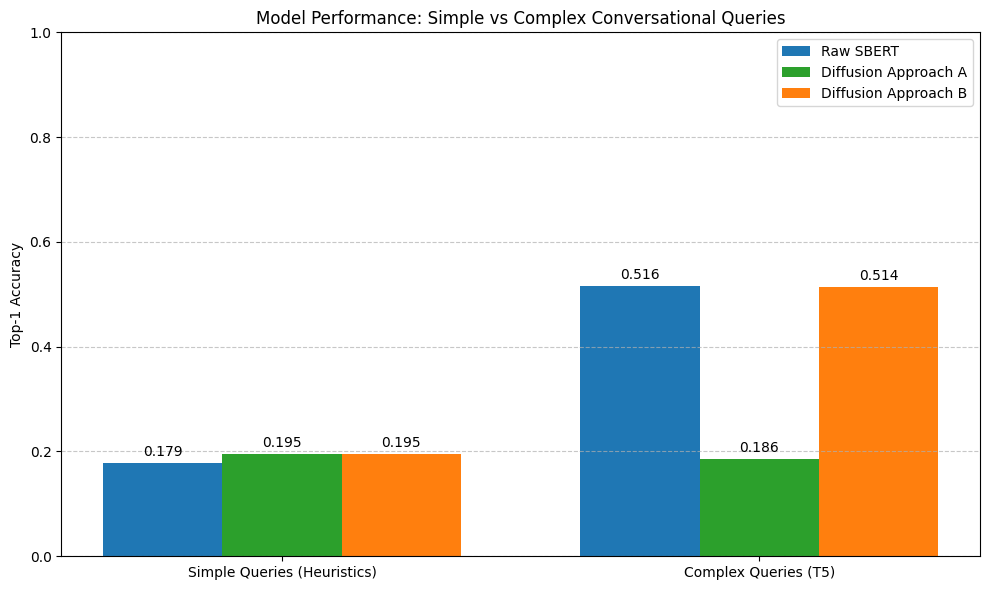

In [17]:
# We'll use the overall metrics for simple queries from your previous run
simple_raw_acc = raw_acc  # Overall raw acc
simple_diff_a_acc = max([res['diff'] for k, res in approach_results.items() if k.startswith('A_')], default=0.0)
simple_diff_b_acc = max([res['diff'] for k, res in approach_results.items() if k.startswith('B_')], default=0.0)

labels = ['Simple Queries (Heuristics)', 'Complex Queries (T5)']
raw_scores = [simple_raw_acc, complex_raw_acc]
diff_a_scores = [simple_diff_a_acc, complex_diff_a_acc]
diff_b_scores = [simple_diff_b_acc, complex_diff_b_acc]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, raw_scores, width, label='Raw SBERT', color='#1f77b4')
rects2 = ax.bar(x, diff_a_scores, width, label='Diffusion Approach A', color='#2ca02c')
rects3 = ax.bar(x + width, diff_b_scores, width, label='Diffusion Approach B', color='#ff7f0e')

ax.set_ylabel('Top-1 Accuracy')
ax.set_title('Model Performance: Simple vs Complex Conversational Queries')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()

# Add text labels on top of the bars
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Real-turn data experiment

These cells keep the original heuristic-query experiment intact, then train a fresh diffusion model on dialogue turns linked to persona facts and evaluate it on both real-turn queries and the existing T5 query set.

In [18]:
# ### Real-turn data experiment: build linked real-turn retrieval data
# This keeps the original heuristic-query experiment unchanged.

import collections
from torch.utils.data import DataLoader, TensorDataset

REAL_LINK_THRESHOLD = 0.42
REAL_LINK_MARGIN = 0.04
REAL_MAX_TURNS_PER_CONV = 80
REAL_MIN_QUERY_WORDS = 4
REAL_MAX_QUERY_WORDS = 45
REAL_RANDOM_SEED = 123

_REAL_DIALOG_KEYS = {"dialog", "dialogs", "dialogue", "dialogues", "conversation", "conversations", "messages", "utterances", "turns", "sessions", "history"}
_REAL_TEXT_KEYS = {"text", "message", "utterance", "content", "value", "response"}
_REAL_SKIP_KEYS = {"persona", "persona1", "persona2", "personas"}

def _real_norm_text(s):
    s = re.sub(r"\s+", " ", str(s)).strip()
    return s.strip('"')

def _real_clean_turn(s):
    s = _real_norm_text(s)
    s = re.sub(r"^(speaker|user|assistant|bot|person|partner|agent)\s*[_-]?\d*\s*[:\-]\s*", "", s, flags=re.I)
    return _real_norm_text(s)

def _real_is_good_turn(s):
    words = s.split()
    if not (REAL_MIN_QUERY_WORDS <= len(words) <= REAL_MAX_QUERY_WORDS):
        return False
    low = s.lower()
    if low.startswith(("persona", "your persona", "partner's persona")):
        return False
    if low in {"hi", "hello", "hey", "yes", "no", "ok", "okay", "thanks", "thank you"}:
        return False
    return any(ch.isalpha() for ch in s)

def _real_collect_dialog_strings(obj, parent_key=""):
    turns = []
    if isinstance(obj, str):
        if parent_key.lower() in _REAL_DIALOG_KEYS or parent_key.lower() in _REAL_TEXT_KEYS:
            turns.append(obj)
        return turns
    if isinstance(obj, dict):
        for k, v in obj.items():
            kl = str(k).lower()
            if kl in _REAL_SKIP_KEYS or "persona" in kl:
                continue
            if kl in _REAL_TEXT_KEYS and isinstance(v, str):
                turns.append(v)
            elif kl in _REAL_DIALOG_KEYS or any(key in kl for key in _REAL_DIALOG_KEYS):
                turns.extend(_real_collect_dialog_strings(v, kl))
            elif isinstance(v, (list, tuple, dict)):
                turns.extend(_real_collect_dialog_strings(v, kl))
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            turns.extend(_real_collect_dialog_strings(item, parent_key))
    return turns

def extract_real_turns(raw):
    turns = []
    for t in _real_collect_dialog_strings(raw):
        t = _real_clean_turn(t)
        if _real_is_good_turn(t):
            turns.append(t)
    out, seen_turns = [], set()
    for t in turns:
        key = t.lower()
        if key not in seen_turns:
            seen_turns.add(key)
            out.append(t)
    return out[:REAL_MAX_TURNS_PER_CONV]

def _real_split_for_conversation(cid):
    h = int(hashlib.md5(str(cid).encode()).hexdigest(), 16) % 100
    return "train" if h < 60 else ("valid" if h < 80 else "test")

def _real_make_corrupted_memory(clean_facts, all_pool, target, seed_key):
    rng = random.Random(int(hashlib.md5(str(seed_key).encode()).hexdigest(), 16))
    clean = list(dict.fromkeys(clean_facts))
    clean_set = {f.lower() for f in clean}
    corrupted = list(clean)
    if clean and rng.random() < CORRUPTION_SEVERITY:
        corrupted.append(contradict(rng.choice(clean)))
    other = [f for f in all_pool if f.lower() not in clean_set]
    if other:
        corrupted.extend(rng.sample(other, min(4, len(other))))
    if target not in corrupted:
        corrupted.append(target)
    rng.shuffle(corrupted)
    return corrupted

print("\n" + "="*60)
print("REAL-TURN DATA: Link dialogue turns to persona facts")
print("="*60)

real_examples = []
real_all_facts = []
real_seen_facts = set()
real_link_stats = collections.Counter()

for rec_idx, raw in enumerate(tqdm(records, desc="Linking real turns")):
    cid = str(raw.get("dialoug_id", raw.get("dialog_id", raw.get("conversation_id", f"conv_{rec_idx}"))))
    clean_facts = [to_third_person(f) for f in get_persona_facts(raw)]
    clean_facts = [f for f in clean_facts if len(f.split()) >= 4]
    turns = extract_real_turns(raw)
    real_link_stats["conversations"] += 1
    real_link_stats["facts"] += len(clean_facts)
    real_link_stats["turns"] += len(turns)
    if len(clean_facts) == 0 or len(turns) == 0:
        continue

    for f in clean_facts:
        fk = f.lower()
        if fk not in real_seen_facts:
            real_seen_facts.add(fk)
            real_all_facts.append(f)

    turn_embs = encode(turns, batch_size=128)
    fact_embs_local = encode(clean_facts, batch_size=128)
    sim = turn_embs @ fact_embs_local.T

    used_pairs = set()
    for ti, turn in enumerate(turns):
        order = np.argsort(sim[ti])[::-1]
        best = int(order[0])
        best_score = float(sim[ti, best])
        second_score = float(sim[ti, order[1]]) if len(order) > 1 else -1.0
        if best_score < REAL_LINK_THRESHOLD:
            continue
        if best_score - second_score < REAL_LINK_MARGIN:
            continue
        pair_key = (turn.lower(), clean_facts[best].lower())
        if pair_key in used_pairs:
            continue
        used_pairs.add(pair_key)
        target = clean_facts[best]
        real_examples.append({
            "example_id": f"real_{cid}_{ti}_{best}",
            "conversation_id": cid,
            "query": turn,
            "target_context": target,
            "clean_memory_facts": clean_facts,
            "link_score": best_score,
            "link_margin": best_score - second_score,
            "split": _real_split_for_conversation(cid),
        })

for ex in real_examples:
    ex["corrupted_memory_facts"] = _real_make_corrupted_memory(
        ex["clean_memory_facts"], real_all_facts, ex["target_context"], ex["example_id"]
    )

real_splits = {s: sum(e["split"] == s for e in real_examples) for s in ["train", "valid", "test"]}
print(f"Found {len(real_examples)} linked real-turn examples")
print(f"Splits: {real_splits}")
print(f"Mean link score: {np.mean([e['link_score'] for e in real_examples]):.3f}" if real_examples else "No links found")
print("Sample links:")
for ex in real_examples[:5]:
    print(f"  Q: {ex['query']}")
    print(f"  A: {ex['target_context']}  score={ex['link_score']:.3f} margin={ex['link_margin']:.3f}")

check(len(real_examples) > 100, "Enough real-turn examples; lower REAL_LINK_THRESHOLD if this fails")
check(all(real_splits[s] > 0 for s in ["train", "valid", "test"]), f"Non-empty real splits: {real_splits}")

print("Embedding real-turn examples...")
real_query_embs = encode([e["query"] for e in real_examples], batch_size=256)
real_target_embs = encode([e["target_context"] for e in real_examples], batch_size=256)
real_per_example_fact_texts = []
real_per_example_fact_embs = []
for ex in tqdm(real_examples, desc="Real fact banks"):
    facts = ex["corrupted_memory_facts"]
    real_per_example_fact_texts.append(facts)
    real_per_example_fact_embs.append(encode(facts, batch_size=128))

real_cond_embs = []
for i, ex in enumerate(real_examples):
    mem_mean = real_per_example_fact_embs[i].mean(axis=0)
    mem_mean = mem_mean / (np.linalg.norm(mem_mean) + 1e-12)
    real_cond_embs.append(np.concatenate([real_query_embs[i], mem_mean]))
real_cond_embs = np.stack(real_cond_embs).astype(np.float32)
real_dim = real_query_embs.shape[1]
real_cond_dim = real_cond_embs.shape[1]
real_train_idx = np.array([i for i, e in enumerate(real_examples) if e["split"] == "train"])
real_val_idx = np.array([i for i, e in enumerate(real_examples) if e["split"] == "valid"])
real_test_idx = np.array([i for i, e in enumerate(real_examples) if e["split"] == "test"])
print(f"real_query_embs={real_query_embs.shape}, real_cond_embs={real_cond_embs.shape}")


REAL-TURN DATA: Link dialogue turns to persona facts


Linking real turns:   0%|          | 0/17940 [00:00<?, ?it/s]

Found 41333 linked real-turn examples
Splits: {'train': 24692, 'valid': 8035, 'test': 8606}
Mean link score: 0.507
Sample links:
  Q: Did you get to do any bow hunting lately?
  A: The user i bow hunt. I remodel homes.  score=0.533 margin=0.057
  Q: It makes good jerky, but not my favorite. What are you favorite meals?
  A: Chicken and macaroni and cheese are some of the user's favorite foods.  score=0.551 margin=0.067
  Q: I love meat, that's my favourite food. My wife likes chicken so it's mostly chicken in the house. My wife's recipe, thai chicken with rice is fantastic. What about you? What's your favourite food?
  A: Chicken and macaroni and cheese are some of the user's favorite foods.  score=0.512 margin=0.112
  Q: Yah, chicken is a staple with us as well. My favorite is jerk chick with red beans and rice. I'm also a big fan of mac n' cheese. How frequently do you cook?
  A: Chicken and macaroni and cheese are some of the user's favorite foods.  score=0.656 margin=0.229
  Q: I t

Real fact banks:   0%|          | 0/41333 [00:00<?, ?it/s]

real_query_embs=(41333, 384), real_cond_embs=(41333, 768)


In [19]:
# ### Real-turn data experiment: train fresh Approach A/B models on real-turn data
# Uses validation to pick Approach B hyperparameters, then reports once on test.

print("\n" + "="*60)
print("REAL-TURN MODEL: Train conditional DDPM")
print("="*60)

REAL_EPOCHS = 40
REAL_T = 100
REAL_BATCH_SIZE = min(256, max(16, len(real_train_idx)))
REAL_LR = 1e-3
REAL_TOP_K = TOP_K
REAL_A_SAMPLES = 4

real_x0_train = torch.tensor(real_target_embs[real_train_idx], dtype=torch.float32, device=DEVICE)
real_c_train = torch.tensor(real_cond_embs[real_train_idx], dtype=torch.float32, device=DEVICE)

real_steps = torch.arange(REAL_T + 1, dtype=torch.float64)
real_alpha_bar_full = torch.cos(((real_steps / REAL_T) + 0.008) / 1.008 * math.pi * 0.5) ** 2
real_alpha_bar_full = real_alpha_bar_full / real_alpha_bar_full[0]
real_betas = 1 - (real_alpha_bar_full[1:] / real_alpha_bar_full[:-1])
real_betas = torch.clip(real_betas, 1e-5, 0.02).float().to(DEVICE)
real_alphas = 1.0 - real_betas
real_alpha_bar = torch.cumprod(real_alphas, dim=0)
real_sqrt_ab = torch.sqrt(real_alpha_bar)
real_sqrt_1ab = torch.sqrt(1 - real_alpha_bar)
real_alpha_bar_prev = torch.cat([torch.ones(1, device=DEVICE), real_alpha_bar[:-1]])
real_post_var = real_betas * (1 - real_alpha_bar_prev) / (1 - real_alpha_bar)

real_model = ConditionalDenoiser(real_dim, real_cond_dim, HIDDEN_DIM, N_LAYERS).to(DEVICE)
if "CHECKPOINT_DIR" not in globals():
    CHECKPOINT_DIR = Path("./cs159_memory_diffusion_checkpoints")
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
if "SAVE_CHECKPOINTS" not in globals(): SAVE_CHECKPOINTS = True
if "LOAD_CHECKPOINTS" not in globals(): LOAD_CHECKPOINTS = True
real_turn_ckpt_name = "real_turn_conditional_ddpm.pt"
real_turn_ckpt_path = CHECKPOINT_DIR / real_turn_ckpt_name
real_turn_ckpt = None
real_turn_loaded = False
if LOAD_CHECKPOINTS:
    if "load_checkpoint_file" in globals():
        real_turn_ckpt, _loaded_path = load_checkpoint_file(real_turn_ckpt_name, map_location=DEVICE)
        if _loaded_path is not None:
            real_turn_ckpt_path = _loaded_path
    elif real_turn_ckpt_path.exists():
        real_turn_ckpt = torch.load(real_turn_ckpt_path, map_location=DEVICE)
if real_turn_ckpt is not None:
    expected = {"real_dim": real_dim, "real_cond_dim": real_cond_dim, "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS, "REAL_T": REAL_T}
    got = {k: real_turn_ckpt.get(k) for k in expected}
    if got == expected:
        real_model.load_state_dict(real_turn_ckpt["model_state_dict"])
        real_model.eval()
        real_history = real_turn_ckpt.get("history", [])
        real_turn_loaded = True
        info(f"Loaded real-turn DDPM from {real_turn_ckpt_path}")
    else:
        info(f"Real-turn checkpoint config mismatch; retraining. expected={expected}, got={got}")

real_loader = DataLoader(
    TensorDataset(real_x0_train, real_c_train),
    batch_size=REAL_BATCH_SIZE,
    shuffle=True,
    drop_last=len(real_train_idx) >= REAL_BATCH_SIZE,
)
real_opt = torch.optim.AdamW(real_model.parameters(), lr=REAL_LR, weight_decay=1e-4)
real_sched = torch.optim.lr_scheduler.CosineAnnealingLR(real_opt, T_max=REAL_EPOCHS)

if real_turn_loaded:
    info("Skipping real-turn DDPM training because checkpoint was loaded.")
else:
    real_history = []
    for epoch in range(1, REAL_EPOCHS + 1):
        real_model.train()
        losses = []
        for x0, cond in real_loader:
            B = x0.shape[0]
            t = torch.randint(0, REAL_T, (B,), device=DEVICE)
            noise = torch.randn_like(x0)
            x_t = real_sqrt_ab[t, None] * x0 + real_sqrt_1ab[t, None] * noise
            pred = real_model(x_t, t, cond)
            loss = torch.nn.functional.mse_loss(pred, noise)
            real_opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(real_model.parameters(), 1.0)
            real_opt.step()
            losses.append(float(loss.item()))
        real_sched.step()
        mean_loss = float(np.mean(losses))
        real_history.append(mean_loss)
        if epoch == 1 or epoch % max(1, REAL_EPOCHS // 10) == 0:
            info(f"Real epoch {epoch}/{REAL_EPOCHS} loss={mean_loss:.6f}")

    if SAVE_CHECKPOINTS:
        real_turn_payload = {
            "model_state_dict": real_model.state_dict(),
            "history": real_history,
            "real_dim": real_dim,
            "real_cond_dim": real_cond_dim,
            "hidden_dim": HIDDEN_DIM,
            "n_layers": N_LAYERS,
            "REAL_T": REAL_T,
            "real_epochs": REAL_EPOCHS,
            "embedding_model": EMBEDDING_MODEL,
            "top_k": REAL_TOP_K,
        }
        if "save_checkpoint_file" in globals():
            save_checkpoint_file(real_turn_payload, real_turn_ckpt_name)
        else:
            torch.save(real_turn_payload, real_turn_ckpt_path)
            info(f"Saved real-turn DDPM checkpoint to {real_turn_ckpt_path}")

real_model.eval()

@torch.no_grad()
def real_generate_prototype(cond, n_samples=REAL_A_SAMPLES):
    B = cond.shape[0]
    cond_rep = cond.repeat(n_samples, 1)
    x = torch.randn(n_samples * B, real_dim, device=DEVICE)
    for i in reversed(range(REAL_T)):
        t = torch.full((n_samples * B,), i, device=DEVICE, dtype=torch.long)
        eps = real_model(x, t, cond_rep)
        a = real_alphas[i]
        ab_i = real_alpha_bar[i]
        b = real_betas[i]
        mean = (1.0 / torch.sqrt(a)) * (x - (b / torch.sqrt(1 - ab_i)) * eps)
        if i > 0:
            mean += torch.sqrt(real_post_var[i]) * torch.randn_like(x)
        x = mean
    x = x.view(n_samples, B, real_dim)
    proto = x.mean(dim=0)
    return proto / (proto.norm(dim=-1, keepdim=True) + 1e-12)

@torch.no_grad()
def real_denoising_score(candidates, cond, t_eval=20):
    B = candidates.shape[0]
    t_eval = min(int(t_eval), REAL_T - 1)
    t = torch.full((B,), t_eval, device=DEVICE, dtype=torch.long)
    noise = torch.randn_like(candidates)
    x_t = real_sqrt_ab[t, None] * candidates + real_sqrt_1ab[t, None] * noise
    cond_rep = cond.expand(B, -1)
    eps_pred = real_model(x_t, t, cond_rep)
    x0_pred = (x_t - real_sqrt_1ab[t, None] * eps_pred) / (real_sqrt_ab[t, None] + 1e-12)
    x0_pred = x0_pred / (x0_pred.norm(dim=-1, keepdim=True) + 1e-12)
    return torch.sum(x0_pred * candidates, dim=-1)

def evaluate_real_split(indices, label, b_t=20, b_alpha=0.5, a_samples=REAL_A_SAMPLES, compute_a=True):
    raw_ok = a_ok = b_ok = oracle_ok = 0
    rows = []
    for i in tqdm(indices, desc=f"Eval real {label}"):
        ex = real_examples[i]
        facts = real_per_example_fact_texts[i]
        fact_embs = real_per_example_fact_embs[i]
        target = ex["target_context"]
        q = real_query_embs[i]
        raw_scores = fact_embs @ q
        order = np.argsort(raw_scores)[::-1]
        topk_idx = order[:min(REAL_TOP_K, len(order))]
        raw_pick = facts[order[0]]
        raw_ok += int(raw_pick.strip().lower() == target.strip().lower())
        oracle_ok += int(any(facts[j].strip().lower() == target.strip().lower() for j in topk_idx))

        cond_t = torch.tensor(real_cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)
        candidate_embs = fact_embs[topk_idx]

        if compute_a:
            proto = real_generate_prototype(cond_t, n_samples=a_samples).cpu().numpy()[0]
            a_scores = candidate_embs @ proto
            a_pick = facts[topk_idx[int(np.argmax(a_scores))]]
            a_ok += int(a_pick.strip().lower() == target.strip().lower())
        else:
            a_pick = None

        cand_t = torch.tensor(candidate_embs, dtype=torch.float32, device=DEVICE)
        d_scores = real_denoising_score(cand_t, cond_t, t_eval=b_t).cpu().numpy()
        b_scores = raw_scores[topk_idx] + b_alpha * d_scores
        b_pick = facts[topk_idx[int(np.argmax(b_scores))]]
        b_ok += int(b_pick.strip().lower() == target.strip().lower())
        rows.append({"query": ex["query"], "target": target, "raw": raw_pick, "a": a_pick, "b": b_pick})

    n = max(1, len(indices))
    result = {
        "label": label,
        "n": len(indices),
        "raw": raw_ok / n,
        "approach_a": (a_ok / n) if compute_a else float("nan"),
        "approach_b": b_ok / n,
        f"top{REAL_TOP_K}_oracle": oracle_ok / n,
        "b_t": b_t,
        "b_alpha": b_alpha,
    }
    print(result)
    return result, rows

if real_turn_ckpt is not None and real_turn_ckpt.get("real_best_b") is not None:
    real_best_b = real_turn_ckpt["real_best_b"]
    real_val_grid = real_turn_ckpt.get("real_val_grid", [])
    print(f"Loaded real validation B choice: t={real_best_b['b_t']} alpha={real_best_b['b_alpha']} acc={real_best_b.get('approach_b', float('nan')):.4f}")
else:
    print("\nTuning Approach B on real validation split...")
    real_val_grid = []
    for t_eval in [5, 10, 20, 40, 80]:
        for alpha in [0.0, 0.25, 0.5, 1.0, 1.5]:
            res, _ = evaluate_real_split(real_val_idx, f"valid_t{t_eval}_a{alpha}", b_t=t_eval, b_alpha=alpha, a_samples=1, compute_a=False)
            real_val_grid.append(res)
    real_best_b = max(real_val_grid, key=lambda r: r["approach_b"])
    print(f"Best real validation B: t={real_best_b['b_t']} alpha={real_best_b['b_alpha']} acc={real_best_b['approach_b']:.4f}")
    if SAVE_CHECKPOINTS:
        real_turn_payload = {
            "model_state_dict": real_model.state_dict(),
            "history": real_history,
            "real_dim": real_dim,
            "real_cond_dim": real_cond_dim,
            "hidden_dim": HIDDEN_DIM,
            "n_layers": N_LAYERS,
            "REAL_T": REAL_T,
            "real_epochs": REAL_EPOCHS,
            "embedding_model": EMBEDDING_MODEL,
            "top_k": REAL_TOP_K,
            "real_best_b": real_best_b,
            "real_val_grid": real_val_grid,
        }
        if "save_checkpoint_file" in globals():
            save_checkpoint_file(real_turn_payload, real_turn_ckpt_name)
        else:
            torch.save(real_turn_payload, real_turn_ckpt_path)
            info(f"Updated real-turn checkpoint with validation choice at {real_turn_ckpt_path}")

real_test_results, real_test_rows = evaluate_real_split(
    real_test_idx,
    "test",
    b_t=real_best_b["b_t"],
    b_alpha=real_best_b["b_alpha"],
    a_samples=REAL_A_SAMPLES,
)
print("\nReal-turn test results:")
for k, v in real_test_results.items():
    print(f"  {k}: {v}")


REAL-TURN MODEL: Train conditional DDPM
No checkpoint found for real_turn_conditional_ddpm.pt. Checked: ['/content/drive/MyDrive/cs159_memory_diffusion_checkpoints/real_turn_conditional_ddpm.pt', '/content/cs159_memory_diffusion_checkpoints/real_turn_conditional_ddpm.pt']
  ℹ Real epoch 1/40 loss=0.532872
  ℹ Real epoch 4/40 loss=0.034818
  ℹ Real epoch 8/40 loss=0.028032
  ℹ Real epoch 12/40 loss=0.027096
  ℹ Real epoch 16/40 loss=0.026229
  ℹ Real epoch 20/40 loss=0.024055
  ℹ Real epoch 24/40 loss=0.023184
  ℹ Real epoch 28/40 loss=0.022144
  ℹ Real epoch 32/40 loss=0.021102
  ℹ Real epoch 36/40 loss=0.020674
  ℹ Real epoch 40/40 loss=0.020951
Saved checkpoint to /content/drive/MyDrive/cs159_memory_diffusion_checkpoints/real_turn_conditional_ddpm.pt
Saved checkpoint to /content/cs159_memory_diffusion_checkpoints/real_turn_conditional_ddpm.pt

Tuning Approach B on real validation split...


Eval real valid_t5_a0.0:   0%|          | 0/8035 [00:00<?, ?it/s]

{'label': 'valid_t5_a0.0', 'n': 8035, 'raw': 0.9863098942128189, 'approach_a': nan, 'approach_b': 0.9863098942128189, 'top5_oracle': 1.0, 'b_t': 5, 'b_alpha': 0.0}


Eval real valid_t5_a0.25:   0%|          | 0/8035 [00:00<?, ?it/s]

{'label': 'valid_t5_a0.25', 'n': 8035, 'raw': 0.9863098942128189, 'approach_a': nan, 'approach_b': 0.9864343497199751, 'top5_oracle': 1.0, 'b_t': 5, 'b_alpha': 0.25}


...

{'label': 'valid_t80_a1.0', 'n': 8035, 'raw': 0.9863098942128189, 'approach_a': nan, 'approach_b': 0.8648413192283758, 'top5_oracle': 1.0, 'b_t': 80, 'b_alpha': 1.0}


Eval real valid_t80_a1.5:   0%|          | 0/8035 [00:00<?, ?it/s]

{'label': 'valid_t80_a1.5', 'n': 8035, 'raw': 0.9863098942128189, 'approach_a': nan, 'approach_b': 0.811076540136901, 'top5_oracle': 1.0, 'b_t': 80, 'b_alpha': 1.5}
Best real validation B: t=5 alpha=0.25 acc=0.9864
Saved checkpoint to /content/drive/MyDrive/cs159_memory_diffusion_checkpoints/real_turn_conditional_ddpm.pt
Saved checkpoint to /content/cs159_memory_diffusion_checkpoints/real_turn_conditional_ddpm.pt


Eval real test:   0%|          | 0/8606 [00:00<?, ?it/s]

{'label': 'test', 'n': 8606, 'raw': 0.9867534278410411, 'approach_a': 0.7825935393911225, 'approach_b': 0.9875668138508018, 'top5_oracle': 1.0, 'b_t': 5, 'b_alpha': 0.25}

Real-turn test results:
  label: test
  n: 8606
  raw: 0.9867534278410411
  approach_a: 0.7825935393911225
  approach_b: 0.9875668138508018
  top5_oracle: 1.0
  b_t: 5
  b_alpha: 0.25


In [20]:
# ### Real-turn data experiment: evaluate the real-turn-trained model on the T5 query dataset
# Run the earlier T5 generation cell first so complex_query_embs/eval_indices/target_facts exist.

print("\n" + "="*60)
print("REAL-TURN MODEL ON T5 QUERIES")
print("="*60)

required_t5_vars = ["complex_query_embs", "eval_indices", "target_facts"]
missing_t5_vars = [name for name in required_t5_vars if name not in globals()]
if missing_t5_vars:
    raise RuntimeError(f"Run the T5 query generation cell first. Missing: {missing_t5_vars}")

real_t5_raw_ok = 0
real_t5_a_ok = 0
real_t5_b_ok = 0
real_t5_oracle_ok = 0
real_t5_rows = []

for idx, i in enumerate(tqdm(eval_indices, desc="Eval real model on T5")):
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = target_facts[idx]
    q = complex_query_embs[idx]

    raw_scores = fact_embs @ q
    order = np.argsort(raw_scores)[::-1]
    topk_idx = order[:min(REAL_TOP_K, len(order))]
    raw_pick = facts[order[0]]
    real_t5_raw_ok += int(raw_pick.strip().lower() == target.strip().lower())
    real_t5_oracle_ok += int(any(facts[j].strip().lower() == target.strip().lower() for j in topk_idx))

    mem_mean = fact_embs.mean(axis=0)
    mem_mean = mem_mean / (np.linalg.norm(mem_mean) + 1e-12)
    cond_new = np.concatenate([q, mem_mean]).astype(np.float32)
    cond_t = torch.tensor(cond_new[None], dtype=torch.float32, device=DEVICE)
    candidate_embs = fact_embs[topk_idx]

    proto = real_generate_prototype(cond_t, n_samples=REAL_A_SAMPLES).cpu().numpy()[0]
    proto_scores = candidate_embs @ proto
    a_pick = facts[topk_idx[int(np.argmax(proto_scores))]]
    real_t5_a_ok += int(a_pick.strip().lower() == target.strip().lower())

    cand_t = torch.tensor(candidate_embs, dtype=torch.float32, device=DEVICE)
    d_scores = real_denoising_score(cand_t, cond_t, t_eval=real_best_b["b_t"]).cpu().numpy()
    b_scores = raw_scores[topk_idx] + real_best_b["b_alpha"] * d_scores
    b_pick = facts[topk_idx[int(np.argmax(b_scores))]]
    real_t5_b_ok += int(b_pick.strip().lower() == target.strip().lower())

    real_t5_rows.append({
        "query": complex_queries[idx] if "complex_queries" in globals() else None,
        "target": target,
        "raw": raw_pick,
        "approach_a": a_pick,
        "approach_b": b_pick,
    })

n_real_t5 = max(1, len(eval_indices))
real_t5_results = {
    "n": len(eval_indices),
    "raw": real_t5_raw_ok / n_real_t5,
    "approach_a": real_t5_a_ok / n_real_t5,
    "approach_b": real_t5_b_ok / n_real_t5,
    f"top{REAL_TOP_K}_oracle": real_t5_oracle_ok / n_real_t5,
    "b_t": real_best_b["b_t"],
    "b_alpha": real_best_b["b_alpha"],
}

print("Real-turn-trained model on T5-query evaluation:")
for k, v in real_t5_results.items():
    print(f"  {k}: {v}")

print("\nSample T5 cases:")
for row in real_t5_rows[:5]:
    print(f"  Q: {row['query']}")
    print(f"  target: {row['target']}")
    print(f"  raw:    {row['raw']}")
    print(f"  A:      {row['approach_a']}")
    print(f"  B:      {row['approach_b']}")


REAL-TURN MODEL ON T5 QUERIES


Eval real model on T5:   0%|          | 0/500 [00:00<?, ?it/s]

Real-turn-trained model on T5-query evaluation:
  n: 500
  raw: 0.516
  approach_a: 0.464
  approach_b: 0.524
  top5_oracle: 0.676
  b_t: 5
  b_alpha: 0.25

Sample T5 cases:
  Q: i go running
  target: The user i go running.
  raw:    The user i go running.
  A:      The user i go running.
  B:      The user i go running.
  Q: Could you tell me more about that?
  target: The user is a parent to 3 kids.
  raw:    The user is very good at certain things.
  A:      The user is very good at certain things.
  B:      The user is very good at certain things.
  Q: Could you tell me more about that?
  target: The user likes to take pictures.
  raw:    The user i used to work in a bank.
  A:      The user i used to work in a bank.
  B:      The user i used to work in a bank.
  Q: man in the user's sixties
  target: The user is a man in the user's sixties.
  raw:    The user is a man in the user's sixties.
  A:      The user is a man in the user's sixties.
  B:      The user is a man in the user

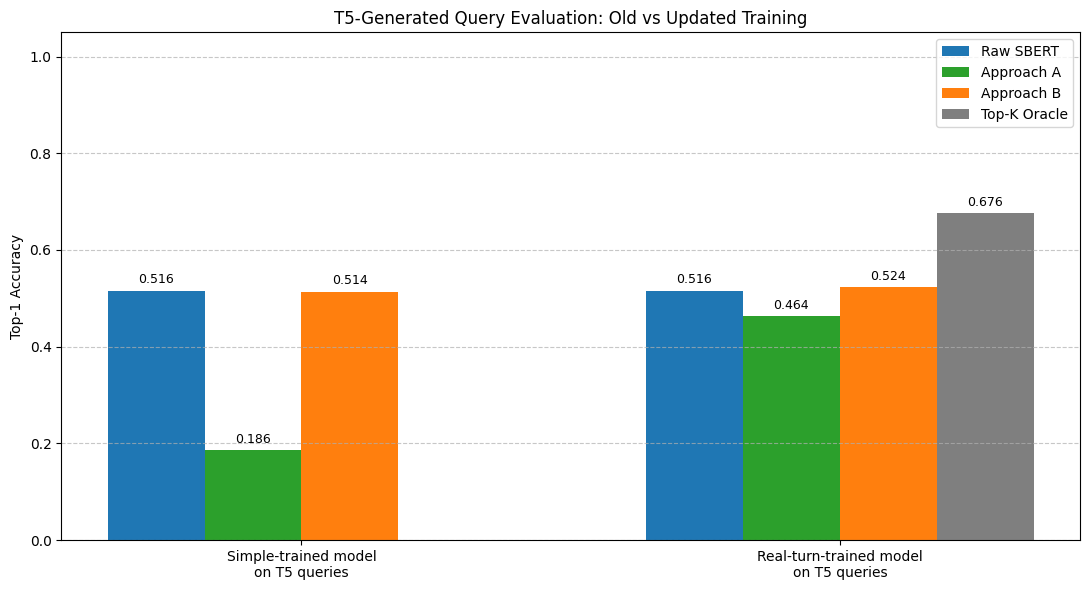

T5 query results plotted:
Simple-trained model on T5 queries
  Raw SBERT: 0.5160
  Approach A: 0.1860
  Approach B: 0.5140
Real-turn-trained model on T5 queries
  Raw SBERT: 0.5160
  Approach A: 0.4640
  Approach B: 0.5240
  Top-K Oracle: 0.6760


In [21]:
# ### Real-turn data experiment: plot updated T5 query results
# Compares T5-query performance before vs after training the new real-turn model.

import matplotlib.pyplot as plt
import numpy as np

required_plot_vars = ["real_t5_results"]
missing_plot_vars = [name for name in required_plot_vars if name not in globals()]
if missing_plot_vars:
    raise RuntimeError(f"Run the real-turn T5 evaluation cell first. Missing: {missing_plot_vars}")

plot_groups = []

# Old/simple-query-trained model on T5 queries, from the earlier T5 evaluation cell.
if all(name in globals() for name in ["complex_raw_acc", "complex_diff_a_acc", "complex_diff_b_acc"]):
    plot_groups.append({
        "label": "Simple-trained model\non T5 queries",
        "Raw SBERT": complex_raw_acc,
        "Approach A": complex_diff_a_acc,
        "Approach B": complex_diff_b_acc,
        "Top-K Oracle": np.nan,
    })

# New/real-turn-trained model on T5 queries.
plot_groups.append({
    "label": "Real-turn-trained model\non T5 queries",
    "Raw SBERT": real_t5_results["raw"],
    "Approach A": real_t5_results["approach_a"],
    "Approach B": real_t5_results["approach_b"],
    "Top-K Oracle": real_t5_results.get(f"top{REAL_TOP_K}_oracle", np.nan),
})

metrics = ["Raw SBERT", "Approach A", "Approach B", "Top-K Oracle"]
colors = {
    "Raw SBERT": "#1f77b4",
    "Approach A": "#2ca02c",
    "Approach B": "#ff7f0e",
    "Top-K Oracle": "#7f7f7f",
}

x = np.arange(len(plot_groups))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))
for offset, metric in enumerate(metrics):
    vals = [group[metric] for group in plot_groups]
    xpos = x + (offset - (len(metrics) - 1) / 2) * width
    bars = ax.bar(xpos, vals, width, label=metric, color=colors[metric])
    for bar, val in zip(bars, vals):
        if np.isnan(val):
            continue
        ax.annotate(
            f"{val:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, val),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_ylabel("Top-1 Accuracy")
ax.set_title("T5-Generated Query Evaluation: Old vs Updated Training")
ax.set_xticks(x)
ax.set_xticklabels([group["label"] for group in plot_groups])
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("T5 query results plotted:")
for group in plot_groups:
    print(group["label"].replace("\n", " "))
    for metric in metrics:
        val = group[metric]
        if not np.isnan(val):
            print(f"  {metric}: {val:.4f}")

## Paper visualizations

These cells generate conference-paper figures that emphasize diffusion-based memory retrieval versus direct similarity scoring. Each figure is saved as a PNG in the current working directory.

In [1]:
# ### Paper figure setup
# Saves all paper figures as PNGs in the notebook's current working directory.

from pathlib import Path
import math
import re
import numpy as np
import matplotlib.pyplot as plt

PAPER_FIG_DIR = Path.cwd()
PAPER_DPI = 220
PAPER_MAX_EVAL = 200  # Set to e.g. 2000 for quick drafts; None uses all available examples.

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": PAPER_DPI,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

PAPER_COLORS = {
    "raw": "#1f77b4",
    "a": "#2ca02c",
    "b": "#ff7f0e",
    "oracle": "#7f7f7f",
    "bm25": "#9467bd",
    "cross": "#8c564b",
    "ensemble": "#d62728",
}

def paper_savefig(filename):
    path = PAPER_FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=PAPER_DPI)
    print(f"Saved {path}")
    plt.show()
    return path

def _paper_value(name, default=np.nan):
    return globals().get(name, default)

def _paper_best(prefix):
    if "approach_results" not in globals():
        return np.nan, None
    candidates = [(k, v) for k, v in approach_results.items() if k.startswith(prefix)]
    if not candidates:
        return np.nan, None
    key, val = max(candidates, key=lambda kv: kv[1].get("diff", -np.inf))
    return val.get("diff", np.nan), key

def _paper_topk_oracle_from_result(result, k=5):
    if not isinstance(result, dict):
        return np.nan
    for key in [f"top{k}_oracle", "top5_oracle", "oracle"]:
        if key in result:
            return result[key]
    return np.nan

print("Paper figures will be saved to:", PAPER_FIG_DIR)

Paper figures will be saved to: /content


In [2]:
# ### Paper figure 1: main performance, improvement over SBERT, and reranking headroom
# Produces:
#   paper_main_performance.png
#   paper_improvement_over_sbert.png
#   paper_topk_headroom.png

rows = []

simple_a, simple_a_key = _paper_best("A_")
simple_b, simple_b_key = _paper_best("B_")
if "raw_acc" in globals():
    rows.append({
        "setting": "Heuristic queries\n(simple-trained)",
        "raw": raw_acc,
        "a": simple_a,
        "b": simple_b,
        "oracle": _paper_value("oracle_acc"),
    })

if all(name in globals() for name in ["complex_raw_acc", "complex_diff_a_acc", "complex_diff_b_acc"]):
    rows.append({
        "setting": "T5 queries\n(simple-trained)",
        "raw": complex_raw_acc,
        "a": complex_diff_a_acc,
        "b": complex_diff_b_acc,
        "oracle": np.nan,
    })

if "real_test_results" in globals():
    rows.append({
        "setting": "Real turns\n(real-trained)",
        "raw": real_test_results["raw"],
        "a": real_test_results["approach_a"],
        "b": real_test_results["approach_b"],
        "oracle": _paper_topk_oracle_from_result(real_test_results, globals().get("REAL_TOP_K", 5)),
    })

if "real_t5_results" in globals():
    rows.append({
        "setting": "T5 queries\n(real-trained)",
        "raw": real_t5_results["raw"],
        "a": real_t5_results["approach_a"],
        "b": real_t5_results["approach_b"],
        "oracle": _paper_topk_oracle_from_result(real_t5_results, globals().get("REAL_TOP_K", 5)),
    })

if not rows:
    raise RuntimeError("No result variables found. Run the evaluation cells first.")

labels = [r["setting"] for r in rows]
metrics = [
    ("raw", "Raw SBERT", PAPER_COLORS["raw"]),
    ("a", "Diffusion A", PAPER_COLORS["a"]),
    ("b", "Diffusion B", PAPER_COLORS["b"]),
    ("oracle", "Top-K oracle", PAPER_COLORS["oracle"]),
]

x = np.arange(len(rows))
width = 0.18
fig, ax = plt.subplots(figsize=(max(10, 2.6 * len(rows)), 6))
for j, (key, name, color) in enumerate(metrics):
    vals = [r.get(key, np.nan) for r in rows]
    xpos = x + (j - (len(metrics)-1)/2) * width
    bars = ax.bar(xpos, vals, width, label=name, color=color)
    for bar, val in zip(bars, vals):
        if np.isnan(val):
            continue
        ax.annotate(f"{val:.3f}", (bar.get_x()+bar.get_width()/2, val), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Top-1 accuracy")
ax.set_title("Memory retrieval performance across query settings")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(ncol=2)
paper_savefig("paper_main_performance.png")

fig, ax = plt.subplots(figsize=(max(9, 2.4 * len(rows)), 5.2))
imp_a = [r["a"] - r["raw"] if not np.isnan(r.get("a", np.nan)) else np.nan for r in rows]
imp_b = [r["b"] - r["raw"] if not np.isnan(r.get("b", np.nan)) else np.nan for r in rows]
width = 0.32
bars_a = ax.bar(x - width/2, imp_a, width, label="Diffusion A - SBERT", color=PAPER_COLORS["a"])
bars_b = ax.bar(x + width/2, imp_b, width, label="Diffusion B - SBERT", color=PAPER_COLORS["b"])
ax.axhline(0, color="black", linewidth=1)
for bars in [bars_a, bars_b]:
    for bar in bars:
        val = bar.get_height()
        if np.isnan(val):
            continue
        offset = 3 if val >= 0 else -13
        ax.annotate(f"{val:+.3f}", (bar.get_x()+bar.get_width()/2, val), xytext=(0, offset),
                    textcoords="offset points", ha="center", va="bottom" if val >= 0 else "top", fontsize=9)
ax.set_ylabel("Accuracy improvement over raw SBERT")
ax.set_title("Diffusion gain over direct similarity scoring")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend()
paper_savefig("paper_improvement_over_sbert.png")

headroom_rows = [r for r in rows if not np.isnan(r.get("oracle", np.nan))]
if headroom_rows:
    labels_h = [r["setting"] for r in headroom_rows]
    xh = np.arange(len(headroom_rows))
    fig, ax = plt.subplots(figsize=(max(8, 2.6 * len(headroom_rows)), 5.5))
    vals_raw = [r["raw"] for r in headroom_rows]
    vals_b = [r["b"] for r in headroom_rows]
    vals_oracle = [r["oracle"] for r in headroom_rows]
    width = 0.24
    ax.bar(xh - width, vals_raw, width, label="Raw SBERT", color=PAPER_COLORS["raw"])
    ax.bar(xh, vals_b, width, label="Diffusion B", color=PAPER_COLORS["b"])
    ax.bar(xh + width, vals_oracle, width, label="Top-K oracle", color=PAPER_COLORS["oracle"])
    for j, vals in enumerate([vals_raw, vals_b, vals_oracle]):
        xpos = xh + (j - 1) * width
        for xx, val in zip(xpos, vals):
            ax.annotate(f"{val:.3f}", (xx, val), xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Top-1 accuracy")
    ax.set_title("Reranking headroom: diffusion vs SBERT and Top-K oracle")
    ax.set_xticks(xh)
    ax.set_xticklabels(labels_h)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend()
    paper_savefig("paper_topk_headroom.png")
else:
    print("Skipped headroom plot: no Top-K oracle metrics available.")

RuntimeError: No result variables found. Run the evaluation cells first.

In [ ]:
# ### Paper figure 2: query distribution and diversity
# Produces:
#   paper_query_distribution.png
#   paper_heuristic_query_templates.png

query_sets = []
if "examples" in globals():
    query_sets.append(("Heuristic\nfact_to_query", [e["query"] for e in examples]))
if "complex_queries" in globals():
    query_sets.append(("T5-generated", list(complex_queries)))
if "real_examples" in globals():
    query_sets.append(("Real dialogue\nturns", [e["query"] for e in real_examples]))

if len(query_sets) < 2:
    raise RuntimeError("Need at least two query sources. Run data/T5/real-turn cells first.")

names = [q[0] for q in query_sets]
counts = [len(qs) for _, qs in query_sets]
unique_counts = [len(set(qs)) for _, qs in query_sets]
lengths = [[len(str(q).split()) for q in qs] for _, qs in query_sets]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(query_sets))
width = 0.36
axes[0].bar(x - width/2, counts, width, label="Total queries", color="#6baed6")
axes[0].bar(x + width/2, unique_counts, width, label="Unique queries", color="#fd8d3c")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_ylabel("Count")
axes[0].set_title("Query diversity by source")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
for xx, total, uniq in zip(x, counts, unique_counts):
    axes[0].annotate(str(total), (xx - width/2, total), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
    axes[0].annotate(str(uniq), (xx + width/2, uniq), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

bins = np.arange(0, max(max(ls) for ls in lengths) + 3) - 0.5
for name, lens in zip(names, lengths):
    axes[1].hist(lens, bins=bins, alpha=0.48, density=True, label=name.replace("\n", " "))
axes[1].set_xlabel("Query length (words)")
axes[1].set_ylabel("Density")
axes[1].set_title("Query length distribution")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
paper_savefig("paper_query_distribution.png")

if "examples" in globals():
    from collections import Counter
    cnt = Counter(e["query"] for e in examples)
    items = cnt.most_common(10)
    labels = [k if len(k) <= 42 else k[:39] + "..." for k, _ in items]
    vals = [v for _, v in items]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    y = np.arange(len(items))
    ax.barh(y, vals, color="#9ecae1")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title("Most frequent heuristic query templates")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    for yy, val in zip(y, vals):
        ax.annotate(str(val), (val, yy), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
    paper_savefig("paper_heuristic_query_templates.png")

In [ ]:
# ### Paper figure 3: real-turn link quality and Approach B validation heatmap
# Produces:
#   paper_real_turn_link_quality.png
#   paper_approach_b_validation_heatmap.png

if "real_examples" in globals() and len(real_examples) > 0 and "link_score" in real_examples[0]:
    scores = np.array([e["link_score"] for e in real_examples], dtype=float)
    margins = np.array([e["link_margin"] for e in real_examples], dtype=float)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].hist(scores, bins=35, color="#74c476", edgecolor="white")
    axes[0].axvline(np.mean(scores), color="black", linestyle="--", label=f"mean={np.mean(scores):.3f}")
    axes[0].set_xlabel("Accepted turn-fact SBERT score")
    axes[0].set_ylabel("Examples")
    axes[0].set_title("Real-turn link confidence")
    axes[0].legend()
    axes[0].grid(axis="y", linestyle="--", alpha=0.3)
    axes[1].hist(margins, bins=35, color="#fdae6b", edgecolor="white")
    axes[1].axvline(np.mean(margins), color="black", linestyle="--", label=f"mean={np.mean(margins):.3f}")
    axes[1].set_xlabel("Best minus second-best fact score")
    axes[1].set_ylabel("Examples")
    axes[1].set_title("Real-turn link margin")
    axes[1].legend()
    axes[1].grid(axis="y", linestyle="--", alpha=0.3)
    paper_savefig("paper_real_turn_link_quality.png")
else:
    print("Skipped real-turn link quality plot: real_examples with link_score/link_margin not found.")

heatmap_sources = []
if "real_val_grid" in globals() and len(real_val_grid) > 0:
    heatmap_sources.append(("Real-turn validation", real_val_grid))

# Build a simple-query heatmap from approach_results if the alpha sweep was run.
if "approach_results" in globals():
    simple_grid = []
    for key, val in approach_results.items():
        m = re.match(r"B_t(?P<t>[0-9]+)_a(?P<a>[0-9.]+)$", key)
        if m:
            simple_grid.append({
                "b_t": int(m.group("t")),
                "b_alpha": float(m.group("a")),
                "approach_b": val.get("diff", np.nan),
            })
    if simple_grid:
        heatmap_sources.insert(0, ("Heuristic validation/test sweep", simple_grid))

if heatmap_sources:
    fig, axes = plt.subplots(1, len(heatmap_sources), figsize=(6 * len(heatmap_sources), 5), squeeze=False)
    for ax, (title, grid) in zip(axes[0], heatmap_sources):
        ts = sorted({int(r["b_t"]) for r in grid})
        alphas = sorted({float(r["b_alpha"]) for r in grid})
        mat = np.full((len(ts), len(alphas)), np.nan)
        for r in grid:
            mat[ts.index(int(r["b_t"])), alphas.index(float(r["b_alpha"]))] = r.get("approach_b", np.nan)
        im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=np.nanmin(mat), vmax=np.nanmax(mat))
        ax.set_xticks(np.arange(len(alphas)))
        ax.set_xticklabels([str(a) for a in alphas])
        ax.set_yticks(np.arange(len(ts)))
        ax.set_yticklabels([str(t) for t in ts])
        ax.set_xlabel("alpha")
        ax.set_ylabel("t_eval")
        ax.set_title(title)
        for ii in range(len(ts)):
            for jj in range(len(alphas)):
                if not np.isnan(mat[ii, jj]):
                    ax.text(jj, ii, f"{mat[ii, jj]:.3f}", ha="center", va="center", color="white" if mat[ii, jj] < np.nanmean(mat) else "black", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Accuracy")
    paper_savefig("paper_approach_b_validation_heatmap.png")
else:
    print("Skipped Approach B heatmap: no real_val_grid or alpha-sweep approach_results found.")

In [ ]:
# ### Paper figure 4: hard examples, rank recovery, and similarity buckets
# Produces:
#   paper_simple_hard_subset_recovery.png
#   paper_simple_rank_recovery.png
#   paper_simple_similarity_buckets.png

required = ["test_idx", "examples", "per_example_fact_texts", "per_example_fact_embs", "query_embs", "cond_embs", "denoising_score"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run the simple-query model/evaluation cells first. Missing: {missing}")

# Pick Approach B settings from the existing sweep when possible.
if "approach_results" in globals():
    b_keys = [k for k in approach_results if k.startswith("B_")]
    best_b_key = max(b_keys, key=lambda k: approach_results[k].get("diff", -np.inf)) if b_keys else None
else:
    best_b_key = None

analysis_t = globals().get("best_t_eval", 20)
analysis_alpha = 0.5
if best_b_key:
    mt = re.search(r"t([0-9]+)", best_b_key)
    ma = re.search(r"_a([0-9.]+)$", best_b_key)
    if mt:
        analysis_t = int(mt.group(1))
    if ma:
        analysis_alpha = float(ma.group(1))

analysis_indices = list(test_idx)
if PAPER_MAX_EVAL is not None:
    analysis_indices = analysis_indices[:PAPER_MAX_EVAL]

records_analysis = []
for i in tqdm(analysis_indices, desc="Paper hard/rank analysis"):
    ex = examples[i]
    facts = per_example_fact_texts[i]
    fact_embs = per_example_fact_embs[i]
    target = ex["target_context"].strip().lower()
    q = query_embs[i]
    scores = fact_embs @ q
    order = np.argsort(scores)[::-1]
    raw_correct = facts[order[0]].strip().lower() == target
    target_positions = [j for j, f in enumerate(facts) if f.strip().lower() == target]
    if not target_positions:
        continue
    target_idx = target_positions[0]
    rank0 = int(np.where(order == target_idx)[0][0]) + 1
    topk_idx = order[:min(TOP_K, len(order))]
    oracle = target_idx in set(topk_idx)
    b_correct = False
    if oracle:
        candidate_t = torch.tensor(fact_embs[topk_idx], dtype=torch.float32, device=DEVICE)
        cond_t = torch.tensor(cond_embs[i:i+1], dtype=torch.float32, device=DEVICE)
        d_scores = denoising_score(candidate_t, cond_t, t_eval=analysis_t).cpu().numpy()
        combined = scores[topk_idx] + analysis_alpha * d_scores
        b_pick_idx = topk_idx[int(np.argmax(combined))]
        b_correct = facts[b_pick_idx].strip().lower() == target
    records_analysis.append({
        "raw_correct": bool(raw_correct),
        "b_correct": bool(b_correct),
        "oracle": bool(oracle),
        "rank": rank0,
        "target_sim": float(scores[target_idx]),
    })

if not records_analysis:
    raise RuntimeError("No analyzable records found for hard/rank analysis.")

hard_records = [r for r in records_analysis if (not r["raw_correct"]) and r["oracle"]]
hard_recovery = np.mean([r["b_correct"] for r in hard_records]) if hard_records else np.nan
fig, ax = plt.subplots(figsize=(7, 5))
vals = [0.0, hard_recovery, 1.0]
labels = ["Raw SBERT\n(by definition)", "Diffusion B\nrecovered", "Top-K oracle"]
colors = [PAPER_COLORS["raw"], PAPER_COLORS["b"], PAPER_COLORS["oracle"]]
bars = ax.bar(labels, vals, color=colors)
for bar, val in zip(bars, vals):
    if not np.isnan(val):
        ax.annotate(f"{val:.3f}", (bar.get_x()+bar.get_width()/2, val), xytext=(0, 3), textcoords="offset points", ha="center")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy on hard subset")
ax.set_title(f"Hard subset: SBERT top-1 wrong, target in top-{TOP_K} (n={len(hard_records)})")
ax.grid(axis="y", linestyle="--", alpha=0.35)
paper_savefig("paper_simple_hard_subset_recovery.png")

rank_vals = sorted({r["rank"] for r in records_analysis if r["rank"] <= TOP_K})
rank_acc = []
rank_n = []
for rk in rank_vals:
    subset = [r for r in records_analysis if r["rank"] == rk]
    rank_acc.append(np.mean([r["b_correct"] for r in subset]))
    rank_n.append(len(subset))
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(r) for r in rank_vals], rank_acc, color=PAPER_COLORS["b"])
for bar, acc, n in zip(bars, rank_acc, rank_n):
    ax.annotate(f"{acc:.3f}\nn={n}", (bar.get_x()+bar.get_width()/2, acc), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Original SBERT rank of correct memory")
ax.set_ylabel("Diffusion B selection accuracy")
ax.set_title("Candidate rank recovery by diffusion reranking")
ax.grid(axis="y", linestyle="--", alpha=0.35)
paper_savefig("paper_simple_rank_recovery.png")

sims = np.array([r["target_sim"] for r in records_analysis])
quantiles = np.quantile(sims, [0, 0.25, 0.5, 0.75, 1.0])
# Avoid duplicate edges if scores are degenerate.
quantiles = np.unique(quantiles)
if len(quantiles) >= 3:
    bucket_labels, raw_bucket, b_bucket, bucket_n = [], [], [], []
    for lo, hi in zip(quantiles[:-1], quantiles[1:]):
        subset = [r for r in records_analysis if (r["target_sim"] >= lo and (r["target_sim"] <= hi if hi == quantiles[-1] else r["target_sim"] < hi))]
        if not subset:
            continue
        bucket_labels.append(f"{lo:.2f}-{hi:.2f}")
        raw_bucket.append(np.mean([r["raw_correct"] for r in subset]))
        b_bucket.append(np.mean([r["b_correct"] for r in subset]))
        bucket_n.append(len(subset))
    x = np.arange(len(bucket_labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width/2, raw_bucket, width, label="Raw SBERT", color=PAPER_COLORS["raw"])
    ax.bar(x + width/2, b_bucket, width, label="Diffusion B", color=PAPER_COLORS["b"])
    ax.set_xticks(x)
    ax.set_xticklabels([f"{lab}\nn={n}" for lab, n in zip(bucket_labels, bucket_n)])
    ax.set_xlabel("Query-target SBERT cosine bucket")
    ax.set_ylabel("Accuracy")
    ax.set_title("Performance by query-target similarity")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend()
    paper_savefig("paper_simple_similarity_buckets.png")
else:
    print("Skipped similarity bucket plot: insufficient unique target similarity values.")

print(f"Approach B settings used for analysis: t_eval={analysis_t}, alpha={analysis_alpha}")